In [1]:
# ============================================================
# SECTION 1 — Chargement et exploration initiale des données
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 150
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)

# Chargement depuis la feuille Feuil2 (les données réelles)
wb = openpyxl.load_workbook(r"C:\Users\HP\Desktop\BASE.xlsx")
ws = wb["Feuil2"]

data = list(ws.iter_rows(values_only=True))

# La ligne 0 contient des noms génériques
# La ligne 1 contient les vrais en-têtes
headers = data[1]
rows = data[2:]

df = pd.DataFrame(rows, columns=headers)

# Renommage des colonnes
df.columns = [
    "Index", "Entity", "Code", "Year",
    "Cellular_Sub", "Internet_Users_Pct",
    "Internet_Users_Count", "Broadband_Sub"
]

df = df.drop(columns=["Index"])

# Conversion en variables numériques
for col in [
    "Cellular_Sub",
    "Internet_Users_Pct",
    "Internet_Users_Count",
    "Broadband_Sub"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Suppression des lignes invalides
df = df.dropna(subset=["Year", "Entity"])

print(f"Shape du dataset : {df.shape}")

print("\nStatistiques descriptives :")
print(df.describe().round(2))

print("\nValeurs manquantes :")
print(df.isnull().sum())

Shape du dataset : (8867, 7)

Statistiques descriptives :
          Year  Cellular_Sub  Internet_Users_Pct  Internet_Users_Count  \
count  8867.00       8867.00             8867.00          8.867000e+03   
mean   2000.15         39.99               17.04          1.089138e+07   
std      11.81         51.98               26.88          1.248841e+08   
min    1980.00          0.00                0.00          0.000000e+00   
25%    1990.00          0.00                0.00          0.000000e+00   
50%    2000.00          5.50                0.86          1.004700e+04   
75%    2010.00         82.23               25.45          8.664195e+05   
max    2020.00        436.10              100.00          4.699886e+09   

       Broadband_Sub  
count        8867.00  
mean            4.44  
std             9.76  
min             0.00  
25%             0.00  
50%             0.00  
75%             2.01  
max            78.52  

Valeurs manquantes :
Entity                  0
Code                

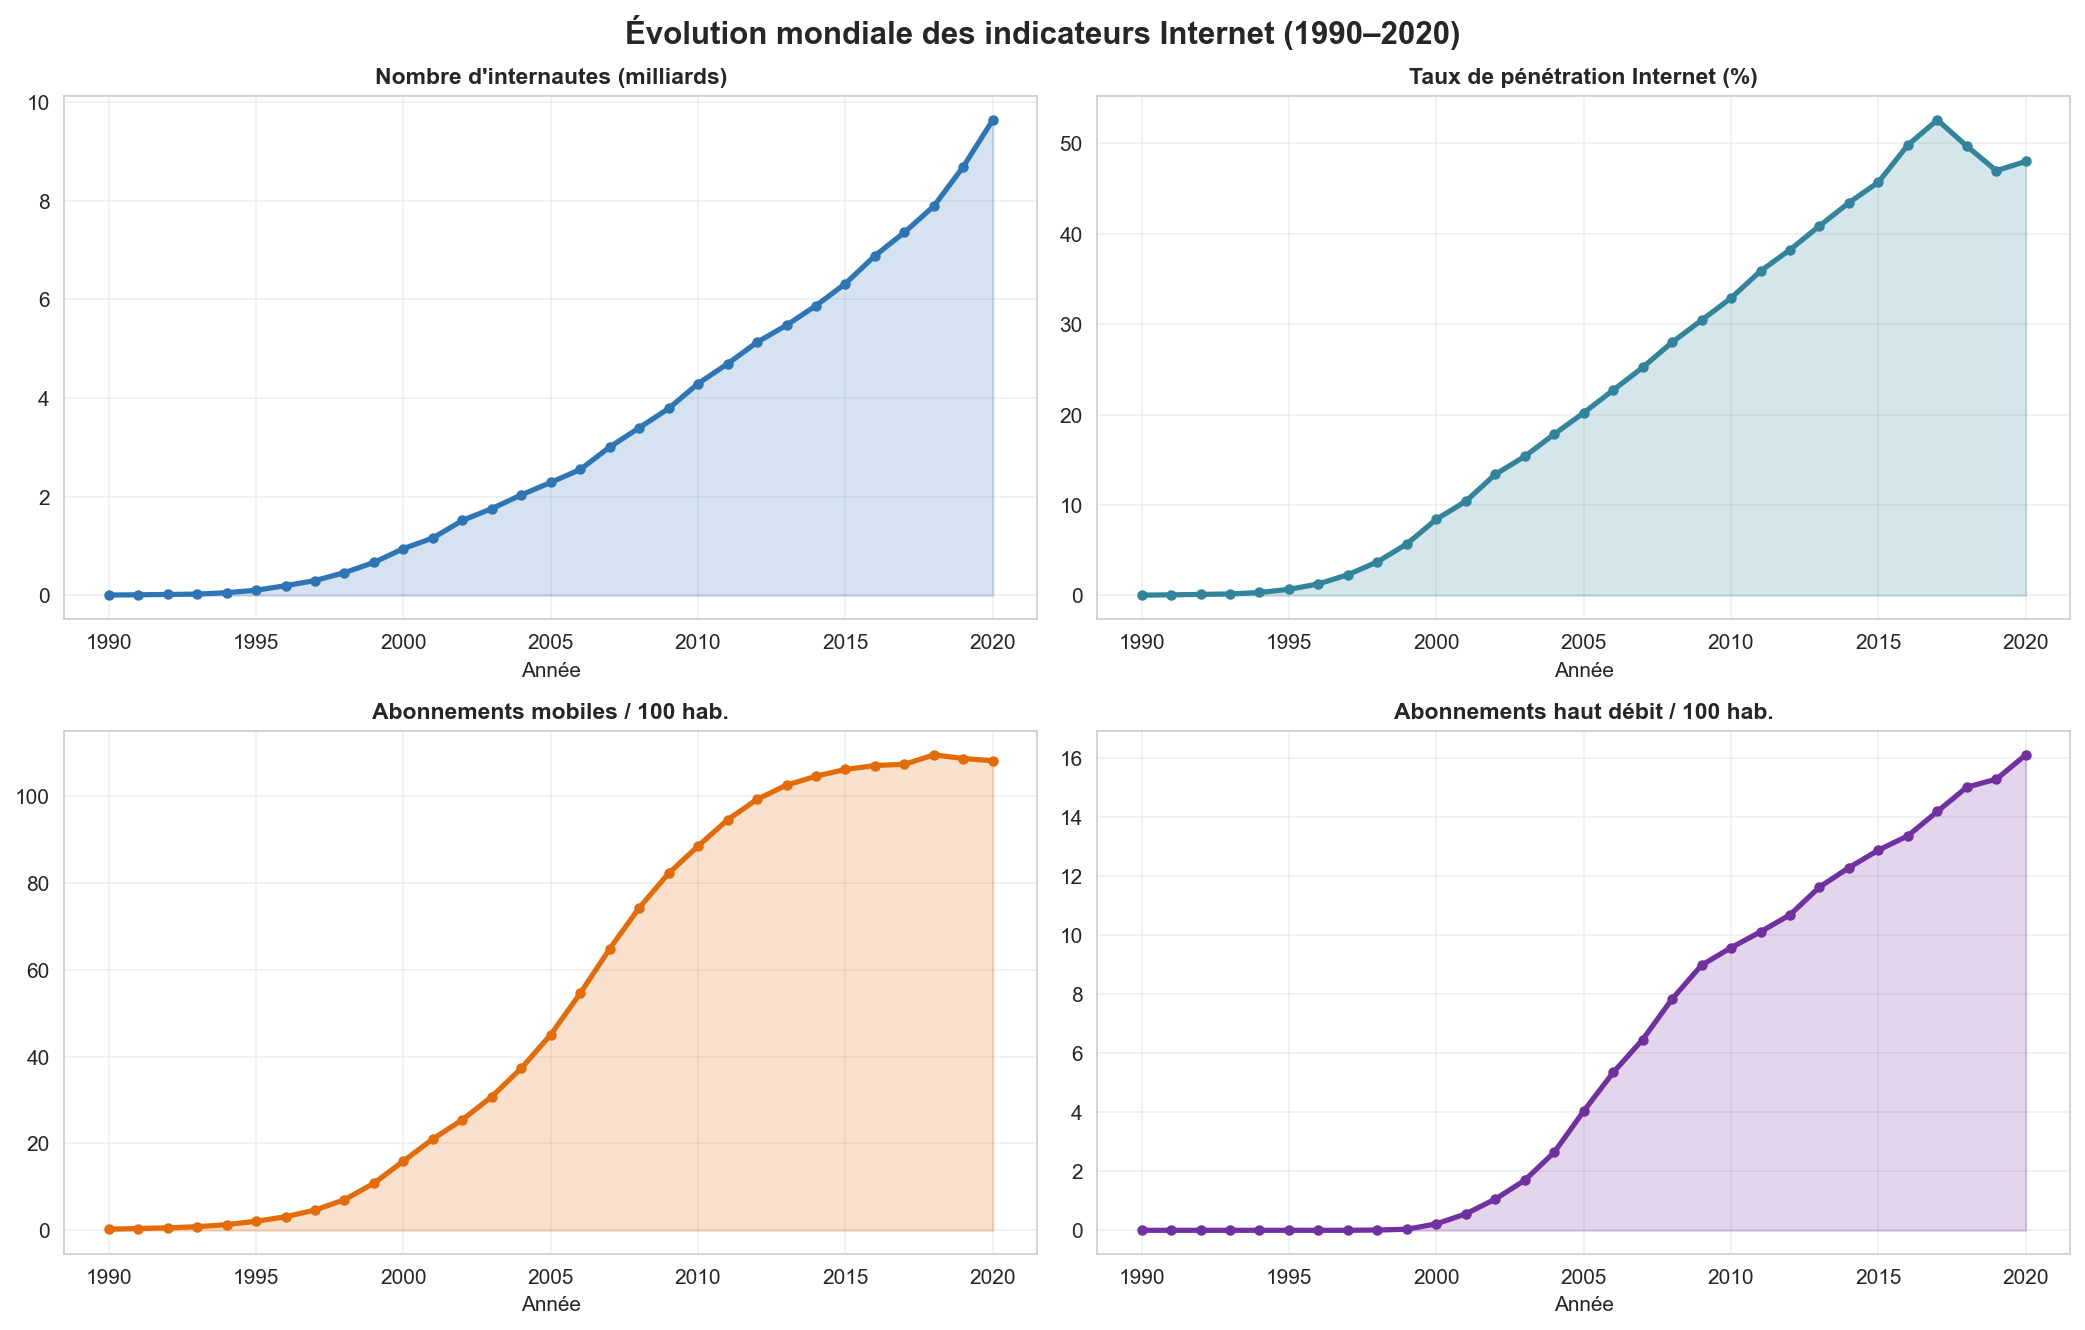

In [2]:
# ================================================================
# SECTION 2- Evolution mondiale des indicateurs internet(tendance)
# ================================================================

# Agrégation mondiale (toutes entités confondues)
world = df.groupby("Year").agg(
    Internet_Users_Count=("Internet_Users_Count", "sum"),
    Cellular_Sub=("Cellular_Sub", "mean"),
    Internet_Users_Pct=("Internet_Users_Pct", "mean"),
    Broadband_Sub=("Broadband_Sub", "mean")
).reset_index()
 
# Restriction aux années significatives (>= 1990)
world = world[world["Year"] >= 1990]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Évolution mondiale des indicateurs Internet (1990–2020)",
             fontsize=15, fontweight="bold")
 
configs = [
    (axes[0,0], "Internet_Users_Count", "#2E75B6",
     "Nombre d'internautes (milliards)", 1e9),
    (axes[0,1], "Internet_Users_Pct", "#31849B",
     "Taux de pénétration Internet (%)", 1),
    (axes[1,0], "Cellular_Sub", "#E36C09",
     "Abonnements mobiles / 100 hab.", 1),
    (axes[1,1], "Broadband_Sub", "#7030A0",
     "Abonnements haut débit / 100 hab.", 1),
]
for ax, col, color, title, divisor in configs:
    vals = world[col] / divisor
    ax.fill_between(world["Year"], vals, alpha=0.2, color=color)
    ax.plot(world["Year"], vals, color=color, linewidth=2.5,
            marker="o", markersize=4)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Année"); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\evolution_mondiale_internet.png",  # Chemin complet
    dpi=300,                    # Haute résolution
    bbox_inches="tight",        # Ajuste les bordures
    facecolor="white"           # Fond blanc
)
plt.show()


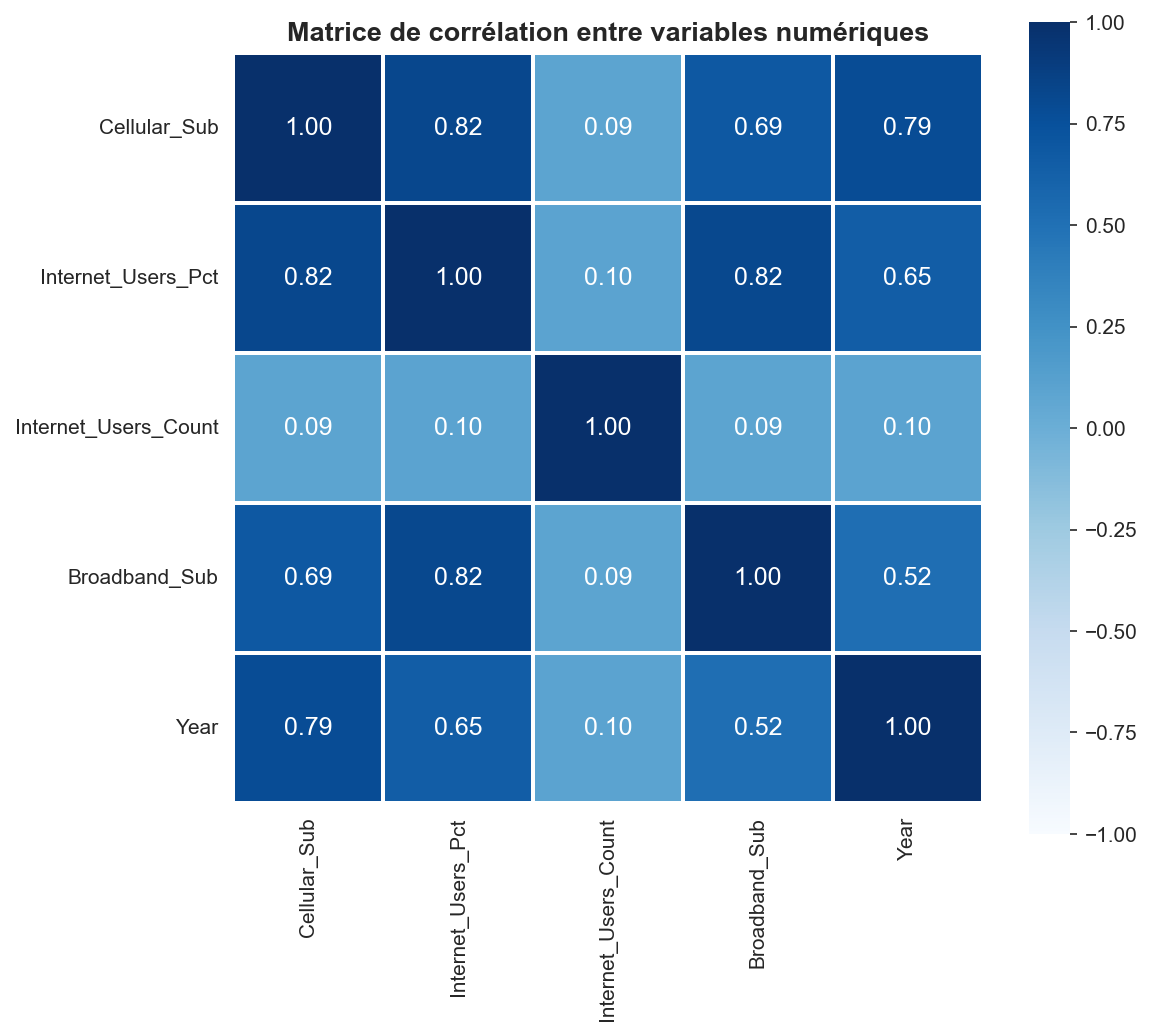

In [3]:
# Matrice de corrélation
corr = df[["Cellular_Sub", "Internet_Users_Pct",
           "Internet_Users_Count", "Broadband_Sub", "Year"]].corr()
 
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            square=True, linewidths=1, ax=ax,
            annot_kws={"size": 12}, vmin=-1, vmax=1)
ax.set_title("Matrice de corrélation entre variables numériques",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\Matrice_de_corrélation.png",  # Chemin complet
    dpi=300,                    # Haute résolution
    bbox_inches="tight",        # Ajuste les bordures
    facecolor="white"           # Fond blanc
)
plt.show()

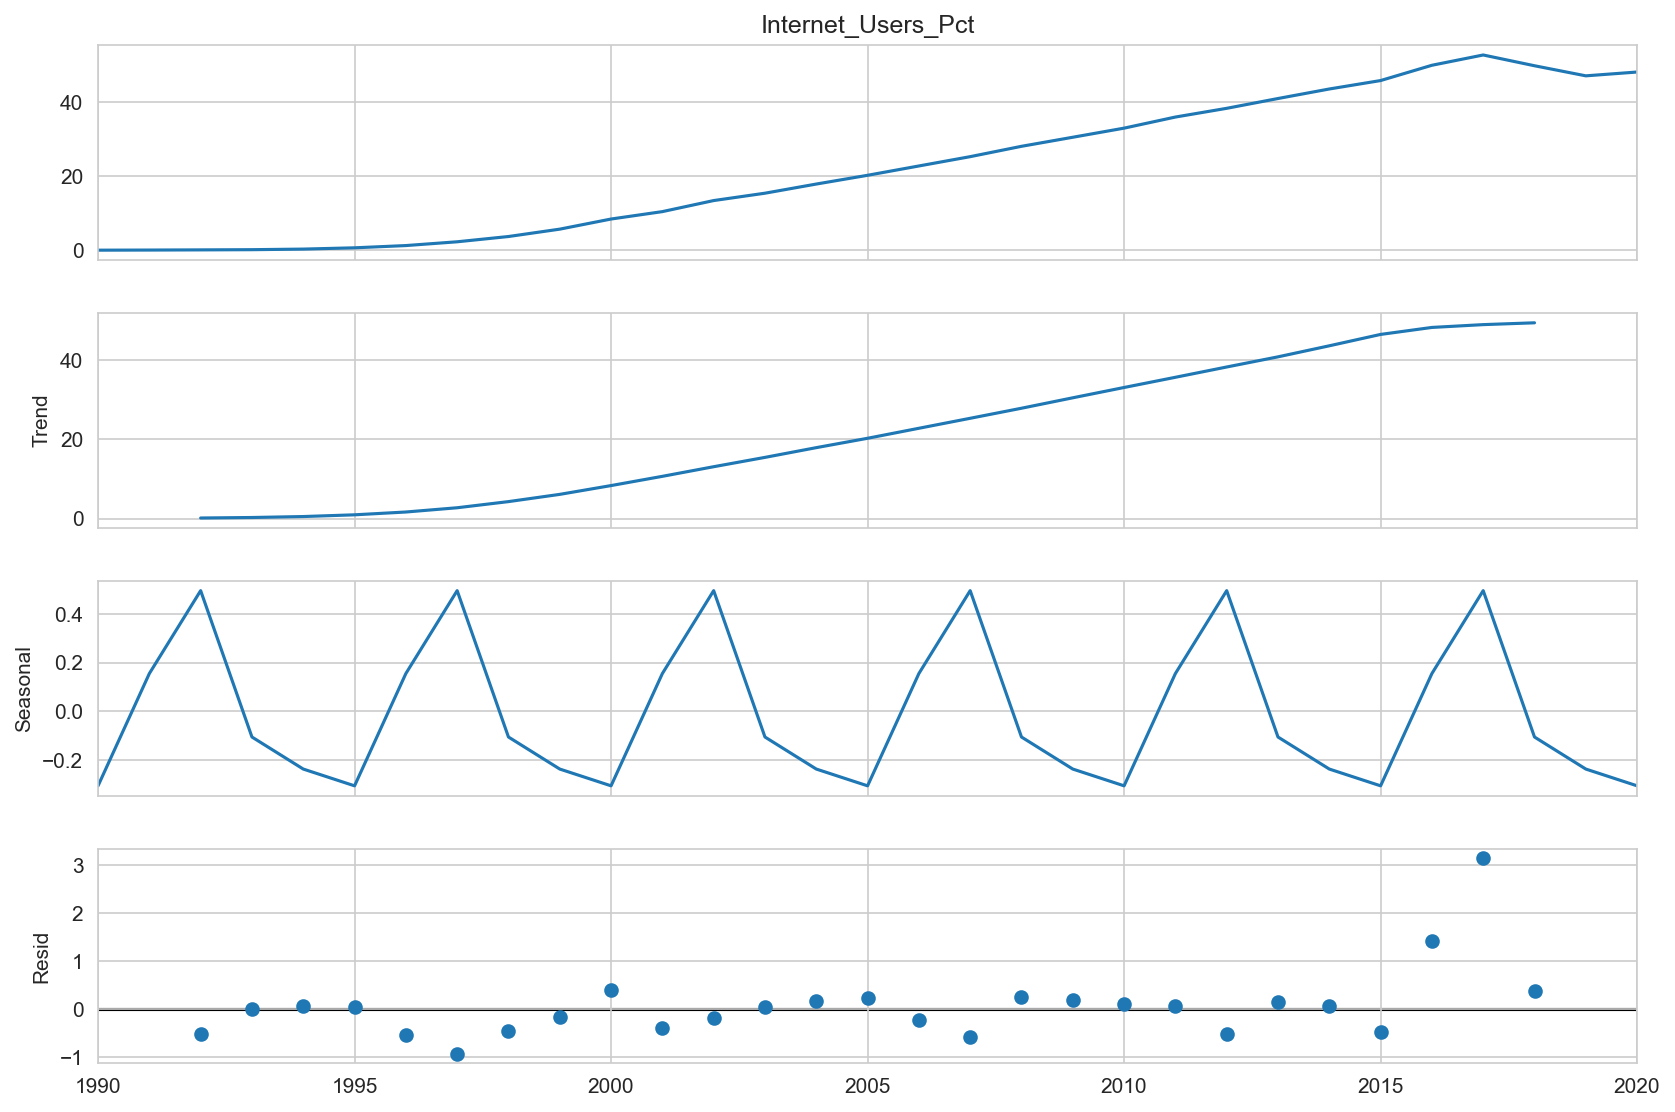

In [4]:
# ============================================================
# SECTION 3 — Analyse de la tendance, saisonnalité et bruit
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose

# Série mondiale du taux d'utilisation d'Internet
ts = world.set_index("Year")["Internet_Users_Pct"]

# Décomposition de la série temporelle
decomposition = seasonal_decompose(ts, model="additive", period=5)

fig = decomposition.plot()
fig.set_size_inches(12,8)

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\decomposition_serie.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

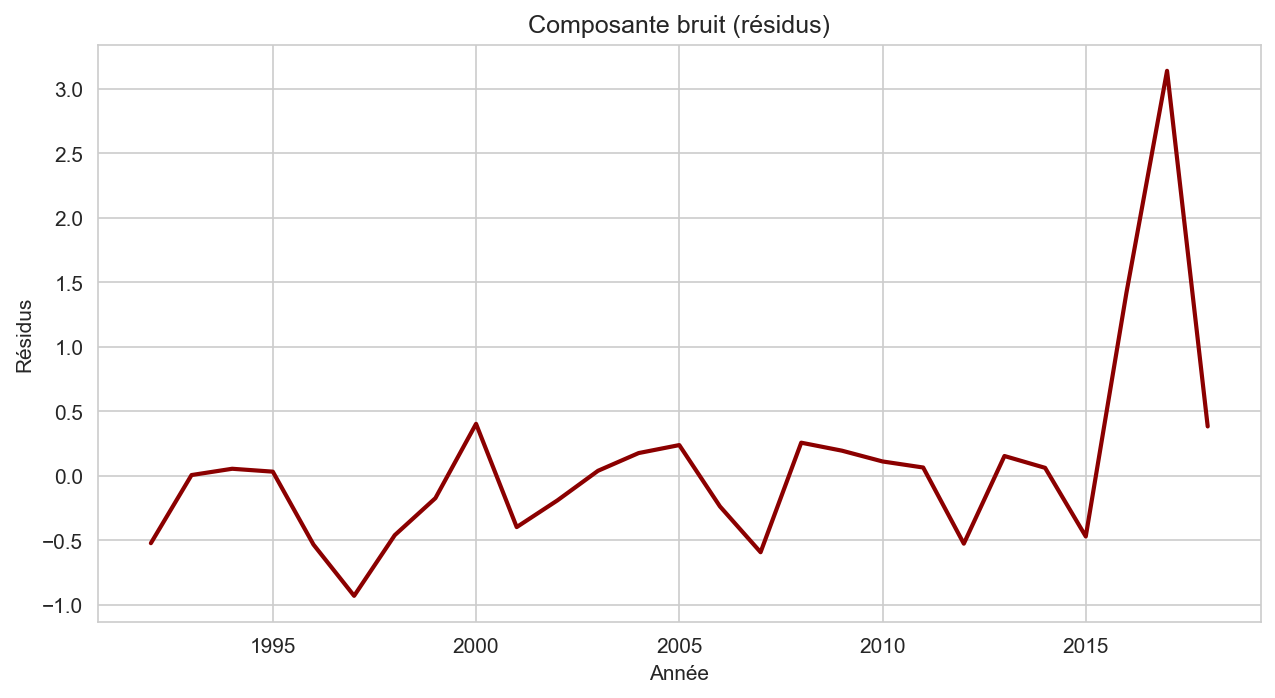

In [5]:
# ============================================================
# SECTION 4 — Analyse du bruit
# ============================================================

residuals = decomposition.resid.dropna()

plt.figure(figsize=(10,5))

plt.plot(residuals, color="darkred", linewidth=2)

plt.title("Composante bruit (résidus)")
plt.xlabel("Année")
plt.ylabel("Résidus")
plt.grid(True)

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\bruit_residus.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

<Figure size 1350x750 with 0 Axes>

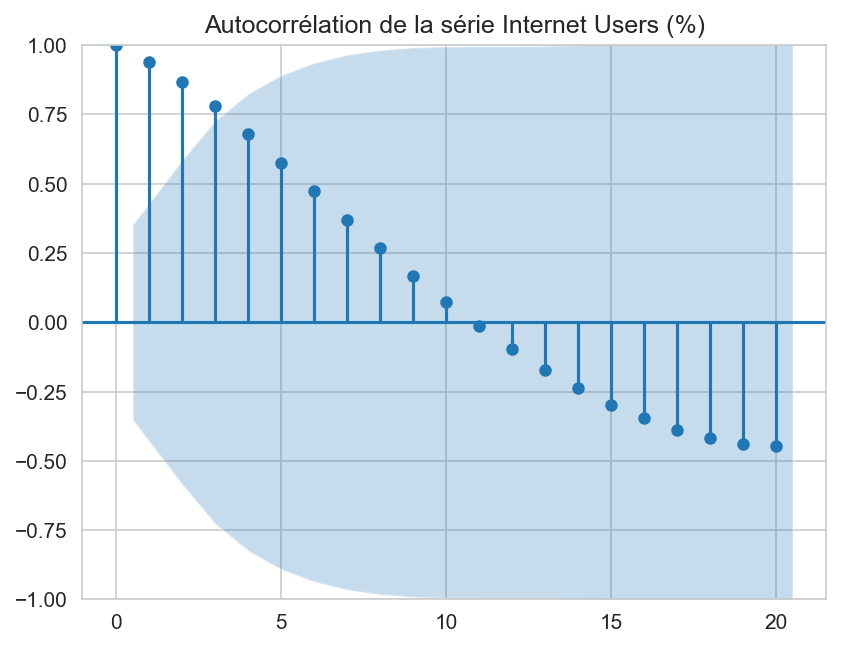

In [6]:
# ============================================================
# SECTION 5 — Autocorrélation
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(9,5))

plot_acf(ts.dropna(), lags=20)

plt.title("Autocorrélation de la série Internet Users (%)")

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\autocorrelation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [7]:
# ==================================================================================
# SECTION 6 — Feature Engineering (création de variables de temps, lags, fenêtres)
# ==================================================================================

# Pays uniquement — codes ISO à 3 lettres (exclut les agrégats régionaux OWID)
df_fe = df[df["Code"].str.len() == 3].copy()

# Tri temporel obligatoire (par entité, puis par année)
df_fe = df_fe.sort_values(["Entity", "Year"])

# =========================
# 1. VARIABLES TEMPORELLES
# =========================
df_fe["Year_norm"] = df_fe["Year"] - df_fe["Year"].min()   # Centrage sur 0
df_fe["Decade"]    = (df_fe["Year"] // 10) * 10            # Décennie

# =========================
# 2. VARIABLES LAG (retards) — calculées par entité pour éviter les fuites inter-pays
# =========================
for lag in [1, 2, 3]:
    df_fe[f"lag_{lag}"] = df_fe.groupby("Entity")["Internet_Users_Pct"].shift(lag)

# =========================
# 3. FENÊTRES GLISSANTES — shift(1) garantit l'absence de data leakage
# =========================
df_fe["rolling_mean_3"] = df_fe.groupby("Entity")["Internet_Users_Pct"] \
    .transform(lambda x: x.shift(1).rolling(3).mean())

df_fe["rolling_std_3"] = df_fe.groupby("Entity")["Internet_Users_Pct"] \
    .transform(lambda x: x.shift(1).rolling(3).std())

# =========================
# 4. TAUX DE CROISSANCE — remplacer les infinis (division par 0 en début de série)
# =========================
df_fe["growth_rate"] = df_fe.groupby("Entity")["Internet_Users_Pct"].pct_change()
df_fe["growth_rate"] = df_fe["growth_rate"].replace([np.inf, -np.inf], np.nan)  # CORRECTION CRITIQUE

# =========================
# 5. NETTOYAGE FINAL
# =========================
df_fe = df_fe.dropna()

print(f"Shape après Feature Engineering : {df_fe.shape}")
print(f"  → {df_fe.shape[0]} observations retenues sur {df['Code'].str.len().eq(3).sum()} initiales")
print("\nAperçu des nouvelles variables :")
cols_show = ["Entity", "Year", "Internet_Users_Pct", "lag_1", "lag_2",
             "rolling_mean_3", "growth_rate"]
df_fe[cols_show].head(8)

Shape après Feature Engineering : (4931, 15)
  → 4931 observations retenues sur 8249 initiales

Aperçu des nouvelles variables :


,Entity,Year,Internet_Users_Pct,lag_1,lag_2,rolling_mean_3,growth_rate
22,Afghanistan,2002,0.004561,0.004723,0.000000,0.001574,-0.034128
23,Afghanistan,2003,0.087891,0.004561,0.004723,0.003095,18.268503
24,Afghanistan,2004,0.105809,0.087891,0.004561,0.032392,0.203863
25,Afghanistan,2005,1.224148,0.105809,0.087891,0.066087,10.569410
26,Afghanistan,2006,2.107124,1.224148,0.105809,0.472616,0.721298
27,Afghanistan,2007,1.900000,2.107124,1.224148,1.145694,-0.098297
28,Afghanistan,2008,1.840000,1.900000,2.107124,1.743757,-0.031579
29,Afghanistan,2009,3.550000,1.840000,1.900000,1.949041,0.929348


--- Z-score (seuil = 2) ---
  Normal   (0) :  4722  observations
  Anomalie (1) :   209  observations  (4.2%)

--- Isolation Forest (contamination = 2%) ---
  Normal   (0) :  4832  observations
  Anomalie (1) :    99  observations


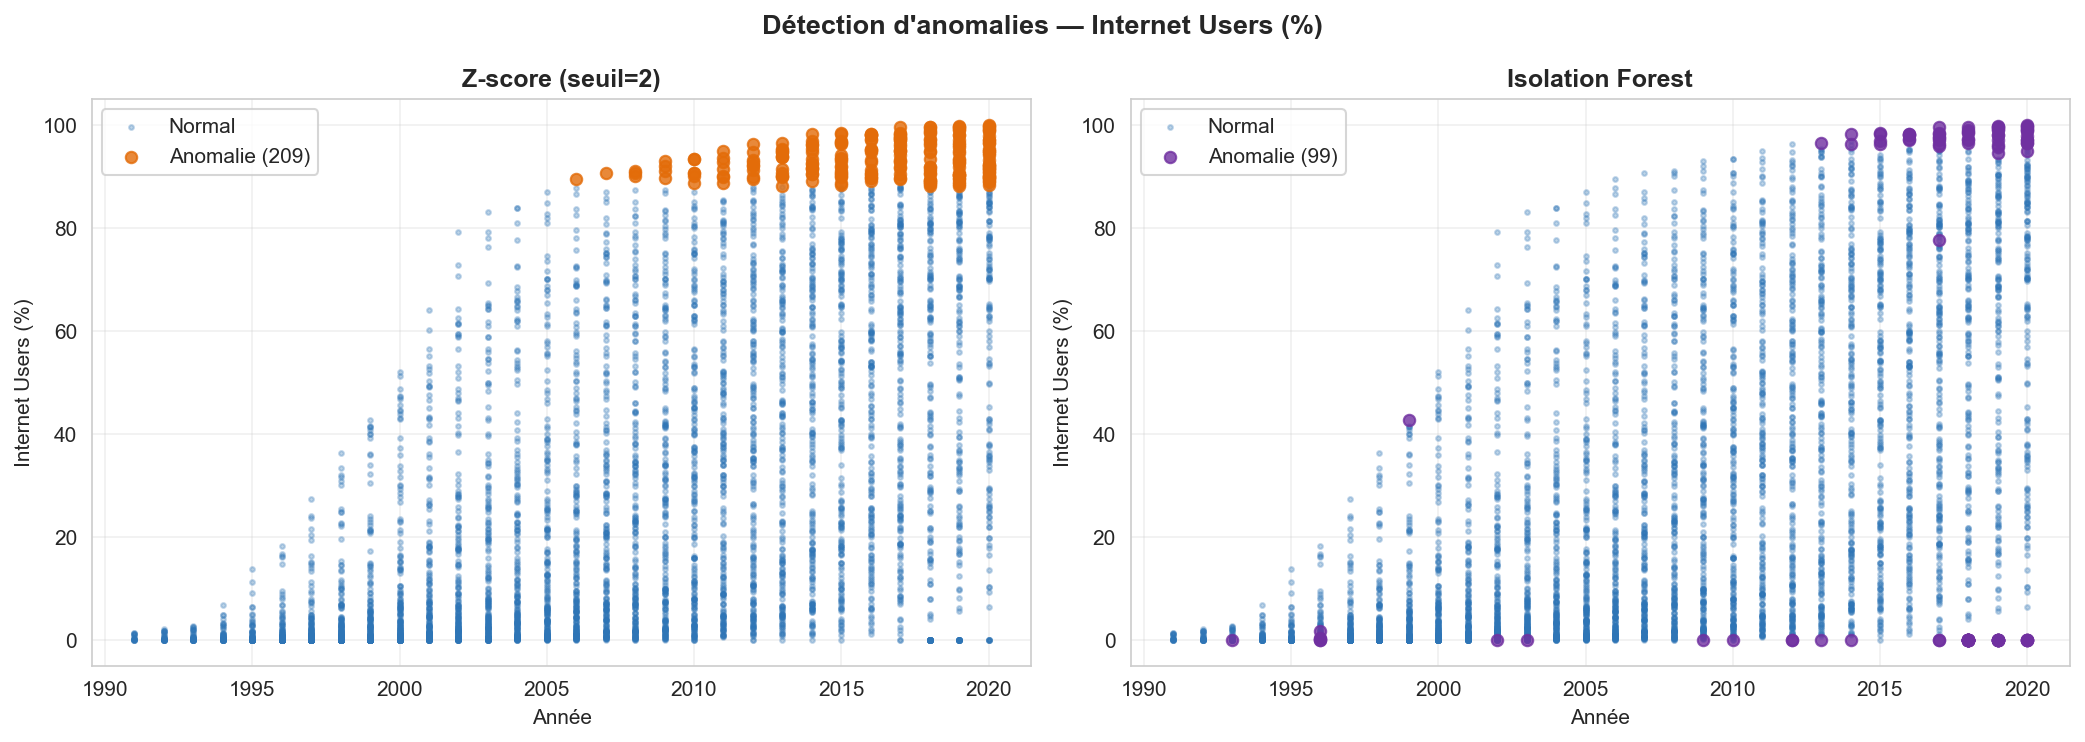


--- Gestion du déséquilibre (SMOTE) ---
  Avant SMOTE : Normal=4832 | Anomalie=99
  Après SMOTE : Normal=4832  | Anomalie=4832
  → Classes équilibrées : ratio 1:1


<Figure size 960x720 with 0 Axes>

In [8]:
# =======================================================
# SECTION 7 — Détection d'anomalies + gestion du déséquilibre
# =======================================================

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

# ----------------------------------------
# 7.1 — Méthode Z-score (seuil = 2)
# ----------------------------------------

# Seuil=2 est approprié pour identifier les variations atypiques significatives.
df_fe["z_score"]   = zscore(df_fe["Internet_Users_Pct"])
df_fe["anomaly_z"] = (np.abs(df_fe["z_score"]) > 2).astype(int)

print("--- Z-score (seuil = 2) ---")
vc_z = df_fe["anomaly_z"].value_counts()
print(f"  Normal   (0) : {vc_z.get(0, 0):>5}  observations")
print(f"  Anomalie (1) : {vc_z.get(1, 0):>5}  observations  ({vc_z.get(1,0)/len(df_fe)*100:.1f}%)")

# ----------------------------------------
# 7.2 — Isolation Forest (ML non supervisé)
# ----------------------------------------
features_if = ["Internet_Users_Pct", "lag_1", "lag_2",
               "rolling_mean_3", "growth_rate"]

iso = IsolationForest(contamination=0.02, random_state=SEED)
df_fe["anomaly_if"] = iso.fit_predict(df_fe[features_if])
df_fe["anomaly_if"] = df_fe["anomaly_if"].map({1: 0, -1: 1})

print("\n--- Isolation Forest (contamination = 2%) ---")
vc_if = df_fe["anomaly_if"].value_counts()
print(f"  Normal   (0) : {vc_if.get(0, 0):>5}  observations")
print(f"  Anomalie (1) : {vc_if.get(1, 0):>5}  observations")

# ----------------------------------------
# Visualisation des anomalies
# ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Détection d'anomalies — Internet Users (%)",
             fontsize=13, fontweight="bold")

for ax, col, label, color in [
    (axes[0], "anomaly_z", "Z-score (seuil=2)", "#E36C09"),
    (axes[1], "anomaly_if", "Isolation Forest", "#7030A0")
]:
    normal  = df_fe[df_fe[col] == 0]
    anomaly = df_fe[df_fe[col] == 1]
    ax.scatter(normal["Year"], normal["Internet_Users_Pct"],
               s=5, alpha=0.3, color="#2E75B6", label="Normal")
    ax.scatter(anomaly["Year"], anomaly["Internet_Users_Pct"],
               s=30, alpha=0.8, color=color,
               label=f"Anomalie ({len(anomaly)})", zorder=5)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Année")
    ax.set_ylabel("Internet Users (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("06_anomalies.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

# ----------------------------------------
# 7.3 — Gestion du déséquilibre (SMOTE)
# ----------------------------------------
# On utilise anomaly_if comme cible (plus équilibré que anomaly_z seuil=2)
X_smote = df_fe[features_if]
y_smote = df_fe["anomaly_if"]

smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

print("\n--- Gestion du déséquilibre (SMOTE) ---")
before = dict(zip(*np.unique(y_smote, return_counts=True)))
after  = dict(zip(*np.unique(y_resampled, return_counts=True)))
print(f"  Avant SMOTE : Normal={before.get(0,0)} | Anomalie={before.get(1,0)}")
print(f"  Après SMOTE : Normal={after.get(0,0)}  | Anomalie={after.get(1,0)}")
print(f"  → Classes équilibrées : ratio 1:1")

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\Detection_Anomalies.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

In [9]:
!pip install arch


TEST DE STATIONNARITÉ
--------------------------------------------------
Série originale:
ADF: 0.2785, p-value: 0.9763
Série différenciée:
ADF: -3.5500, p-value: 0.0068

ESTIMATION ARIMA(1,1,1)
--------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:     Internet_Users_Pct   No. Observations:                   31
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -49.271
Date:                Tue, 24 Mar 2026   AIC                            104.541
Time:                        12:28:11   BIC                            108.745
Sample:                             0   HQIC                           105.886
                                 - 31                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

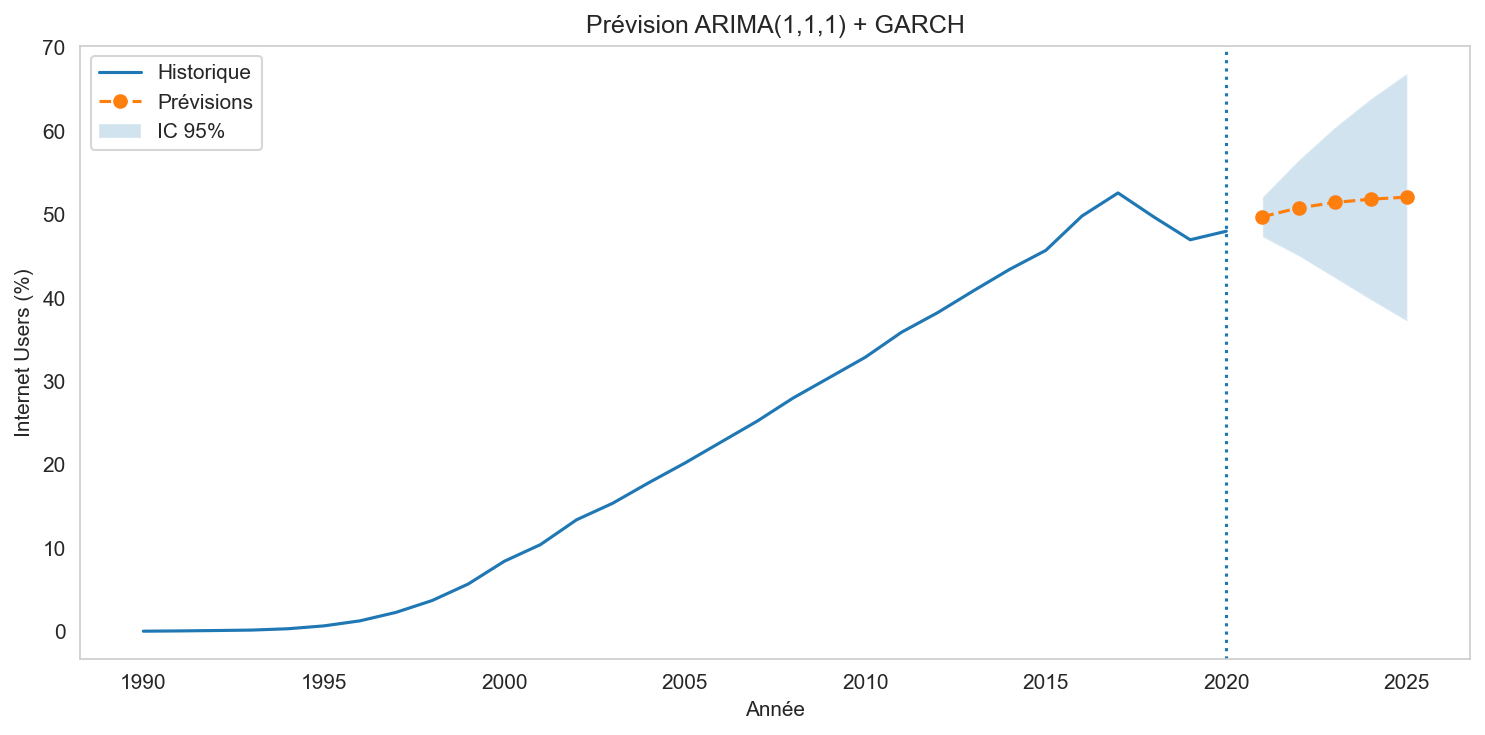

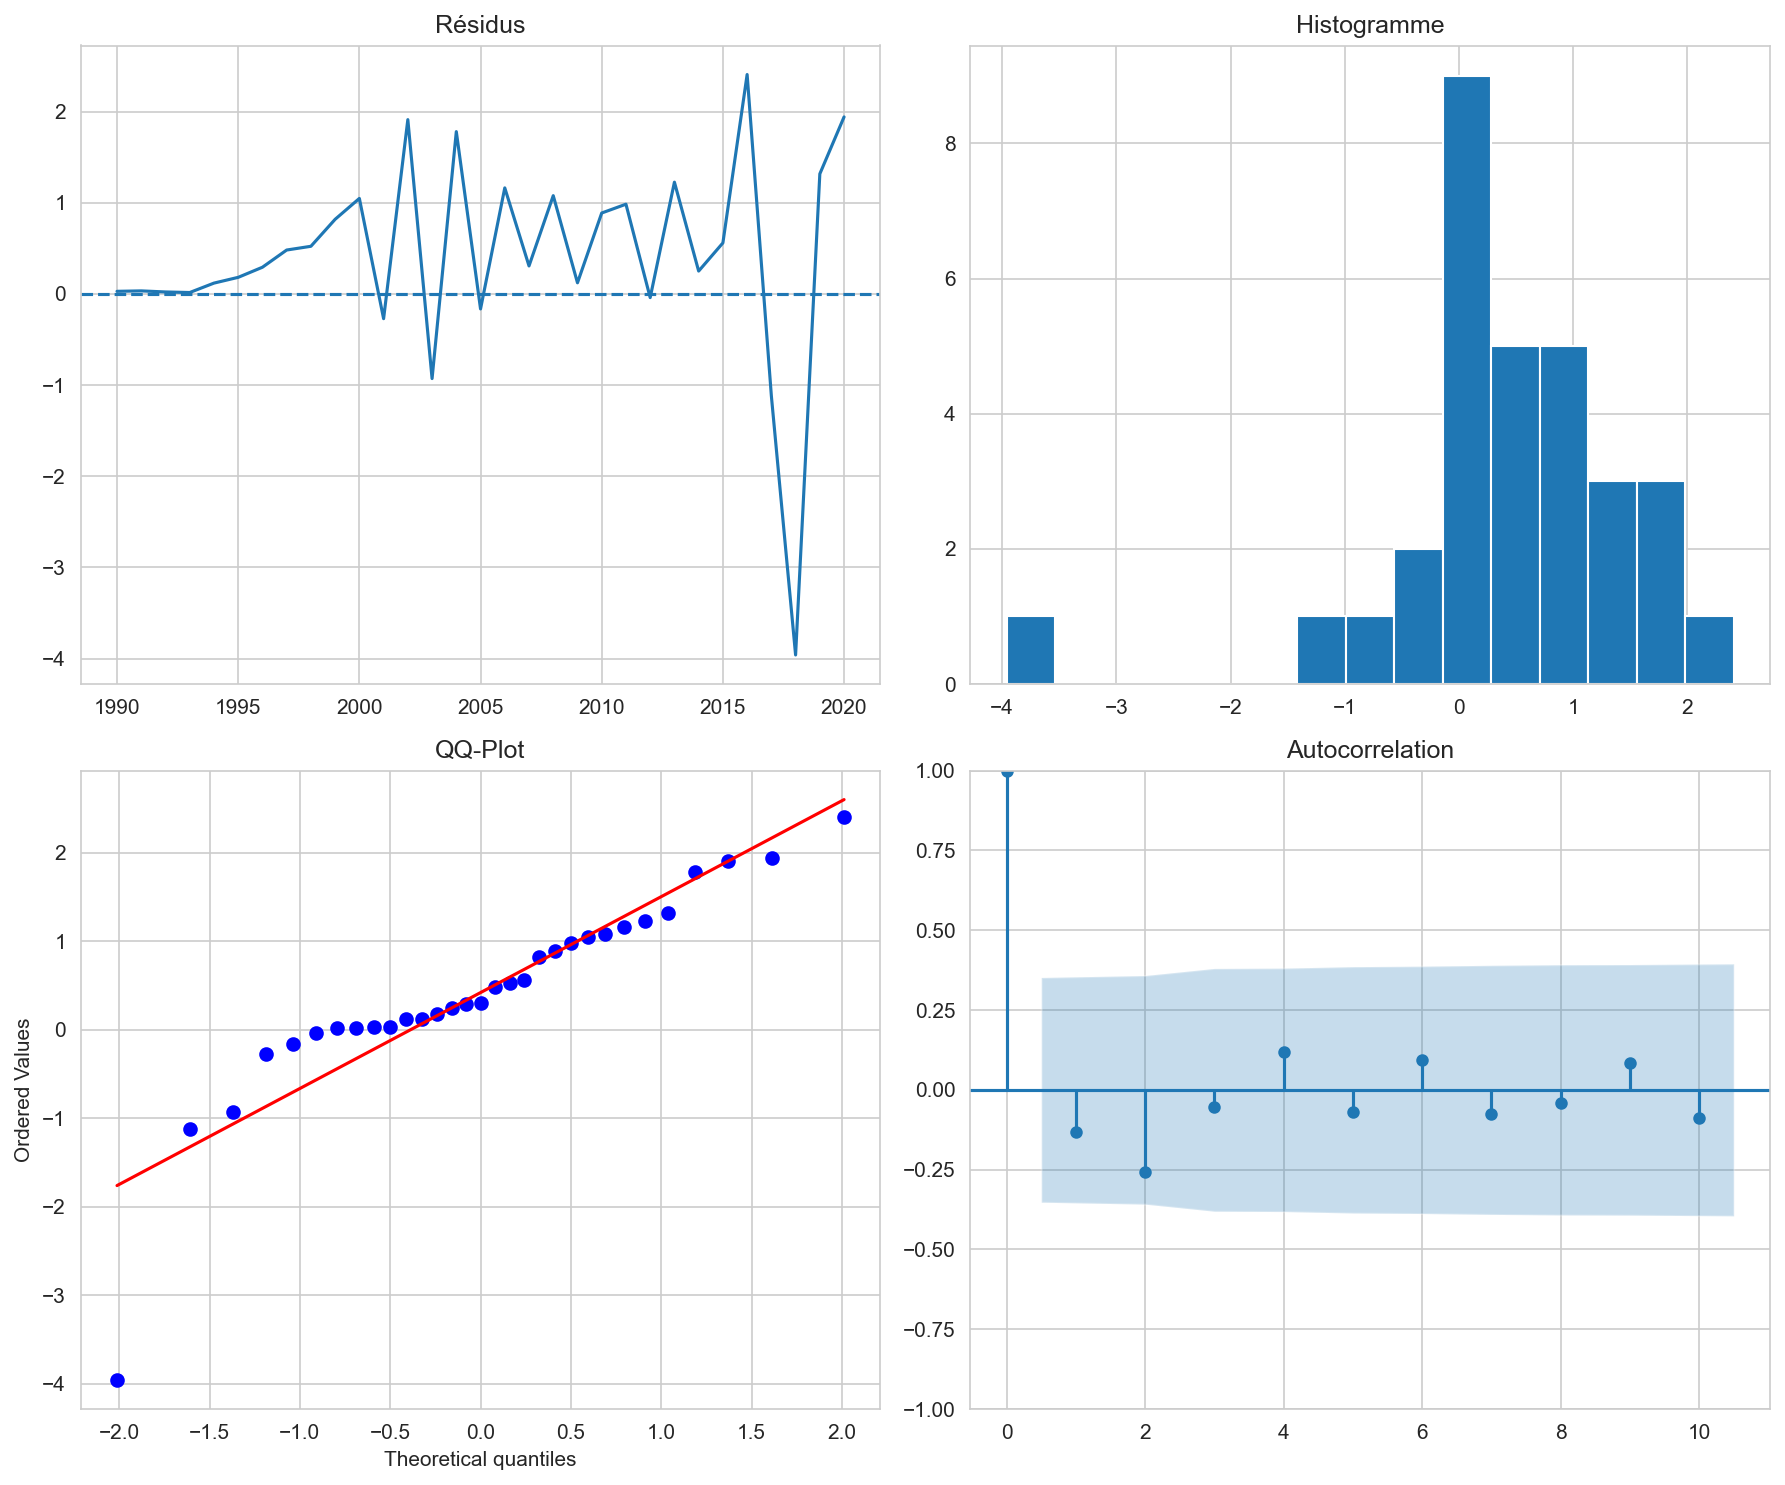

In [9]:
# ===============================================
# SECTION 8 — MODÈLE OPTIMAL ARIMA + GARCH
# ===============================================

import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model

from scipy import stats
from scipy.stats import jarque_bera

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===============================================
# 1. PRÉPARATION DES DONNÉES
# ===============================================

ts_model = world.set_index("Year")["Internet_Users_Pct"].dropna()

# ===============================================
# 2. TEST DE STATIONNARITÉ (ADF)
# ===============================================

print("\nTEST DE STATIONNARITÉ")
print("-"*50)

adf_original = adfuller(ts_model)
print("Série originale:")
print(f"ADF: {adf_original[0]:.4f}, p-value: {adf_original[1]:.4f}")

ts_diff = ts_model.diff().dropna()
adf_diff = adfuller(ts_diff)

print("Série différenciée:")
print(f"ADF: {adf_diff[0]:.4f}, p-value: {adf_diff[1]:.4f}")

# ===============================================
# 3. MODÈLE ARIMA(1,1,1)
# ===============================================

print("\nESTIMATION ARIMA(1,1,1)")
print("-"*50)

model_arima = ARIMA(ts_model, order=(1, 1, 1))
model_fit = model_arima.fit()

print(model_fit.summary())

# ===============================================
# 4. ANALYSE DES RÉSIDUS ARIMA
# ===============================================

residuals = model_fit.resid.dropna()

print("\nANALYSE DES RÉSIDUS ARIMA")
print("-"*50)

print(f"Moyenne: {residuals.mean():.4f}")
print(f"Écart-type: {residuals.std():.4f}")

# Normalité
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro p-value: {shapiro_test[1]:.4f}")

# Autocorrélation
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box p-value: {ljung_box['lb_pvalue'].values[0]:.4f}")

# ===============================================
# 5. MODÈLE GARCH(1,1)
# ===============================================

print("\nESTIMATION GARCH(1,1)")
print("-"*50)

garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

# Résidus standardisés
std_resid = garch_fit.std_resid

# ===============================================
# 6. VALIDATION FINALE
# ===============================================

print("\nVALIDATION FINALE")
print("-"*50)

lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)
jb_test = jarque_bera(std_resid)

print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"Jarque-Bera p-value: {jb_test[1]:.4f}")

# ===============================================
# 7. PRÉVISIONS
# ===============================================

forecast_steps = 5
forecast_arima = model_fit.forecast(steps=forecast_steps)

forecast_years = list(range(int(ts_model.index[-1]) + 1,
                            int(ts_model.index[-1]) + 1 + forecast_steps))

print("\nPRÉVISIONS")
print("-"*50)

for yr, val in zip(forecast_years, forecast_arima):
    print(f"{yr}: {val:.2f} %")

# ===============================================
# 8. INTERVALLES DE CONFIANCE
# ===============================================

forecast_result = model_fit.get_forecast(steps=forecast_steps)
conf_int = forecast_result.conf_int()

# ===============================================
# 9. BACKTESTING
# ===============================================

print("\nBACKTESTING")
print("-"*50)

train_size = len(ts_model) - 5
train_data = ts_model[:train_size]
test_data = ts_model[train_size:]

model_bt = ARIMA(train_data, order=(1, 1, 1))
fit_bt = model_bt.fit()

predictions = fit_bt.forecast(steps=5)

mae = mean_absolute_error(test_data, predictions)
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mape = np.mean(np.abs((test_data.values - predictions.values) / test_data.values)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# ===============================================
# 10. VISUALISATION
# ===============================================

plt.figure(figsize=(10,5))

plt.plot(ts_model.index, ts_model.values, label="Historique")
plt.plot(forecast_years, forecast_arima, linestyle='--', marker='o', label="Prévisions")

plt.fill_between(forecast_years,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.2,
                 label="IC 95%")

plt.axvline(x=ts_model.index[-1], linestyle=":")

plt.title("Prévision ARIMA(1,1,1) + GARCH")
plt.xlabel("Année")
plt.ylabel("Internet Users (%)")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\forecast_arima_garch.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ===============================================
# 11. DIAGNOSTICS
# ===============================================

fig, axes = plt.subplots(2,2, figsize=(12,10))

axes[0,0].plot(residuals)
axes[0,0].axhline(0, linestyle='--')
axes[0,0].set_title("Résidus")

axes[0,1].hist(residuals, bins=15)
axes[0,1].set_title("Histogramme")

stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title("QQ-Plot")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, ax=axes[1,1], lags=10)

plt.tight_layout()

plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\diagnostics_arima_garch.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


In [10]:
# ==========================================================
# SECTION 9 — Random Forest (supervisé)
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

features = ["lag_1", "lag_2", "lag_3",
            "rolling_mean_3", "rolling_std_3",
            "growth_rate", "Year_norm"]

X = df_fe[features]
y = df_fe["Internet_Users_Pct"]

# Split temporel strict (80 % train / 20 % test)
split   = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]

print(f"Train : {len(X_train)} observations")
print(f"Test  : {len(X_test)}  observations")

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\n--- Métriques Random Forest ---")
print(f"  RMSE : {rmse_rf:.4f} points de %")
print(f"  MAE  : {mae_rf:.4f} points de %")
print(f"  R²   : {r2_rf:.4f}")

# Importance des variables (Gini)
importances_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables (Gini) :")
print(importances_rf.round(4).to_string())

Train : 3944 observations
Test  : 987  observations

--- Métriques Random Forest ---
  RMSE : 0.9599 points de %
  MAE  : 0.3681 points de %
  R²   : 0.9990

Importance des variables (Gini) :
lag_1             0.8531
rolling_mean_3    0.0594
growth_rate       0.0557
lag_2             0.0310
lag_3             0.0005
rolling_std_3     0.0003
Year_norm         0.0001


In [11]:
# ==========================================================
# SECTION 10 — Gradient Boosting (équivalent XGBoost)
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=SEED
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("--- Métriques Gradient Boosting ---")
print(f"  RMSE : {rmse_gb:.4f} points de %")
print(f"  MAE  : {mae_gb:.4f} points de %")
print(f"  R²   : {r2_gb:.4f}")

importances_gb = pd.Series(gb.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables (Gain) :")
print(importances_gb.round(4).to_string())

--- Métriques Gradient Boosting ---
  RMSE : 0.7367 points de %
  MAE  : 0.2872 points de %
  R²   : 0.9994

Importance des variables (Gain) :
lag_1             0.8841
growth_rate       0.0579
rolling_mean_3    0.0578
rolling_std_3     0.0002
lag_2             0.0000
lag_3             0.0000
Year_norm         0.0000


In [12]:
# ==========================================================
# SECTION 11 — Régression Linéaire (Baseline)
# ==========================================================

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("--- Métriques Régression Linéaire ---")
print(f"  RMSE : {rmse_lr:.4f} points de %")
print(f"  MAE  : {mae_lr:.4f} points de %")
print(f"  R²   : {r2_lr:.4f}")

--- Métriques Régression Linéaire ---
  RMSE : 5.5392 points de %
  MAE  : 2.5960 points de %
  R²   : 0.9664


=== COMPARAISON DES MODÈLES ===
             Modèle   RMSE    MAE     R²
  Gradient Boosting 0.7367 0.2872 0.9994
      Random Forest 0.9599 0.3681 0.9990
Régression Linéaire 5.5392 2.5960 0.9664

✓ Meilleur modèle : Gradient Boosting (RMSE = 0.7367)


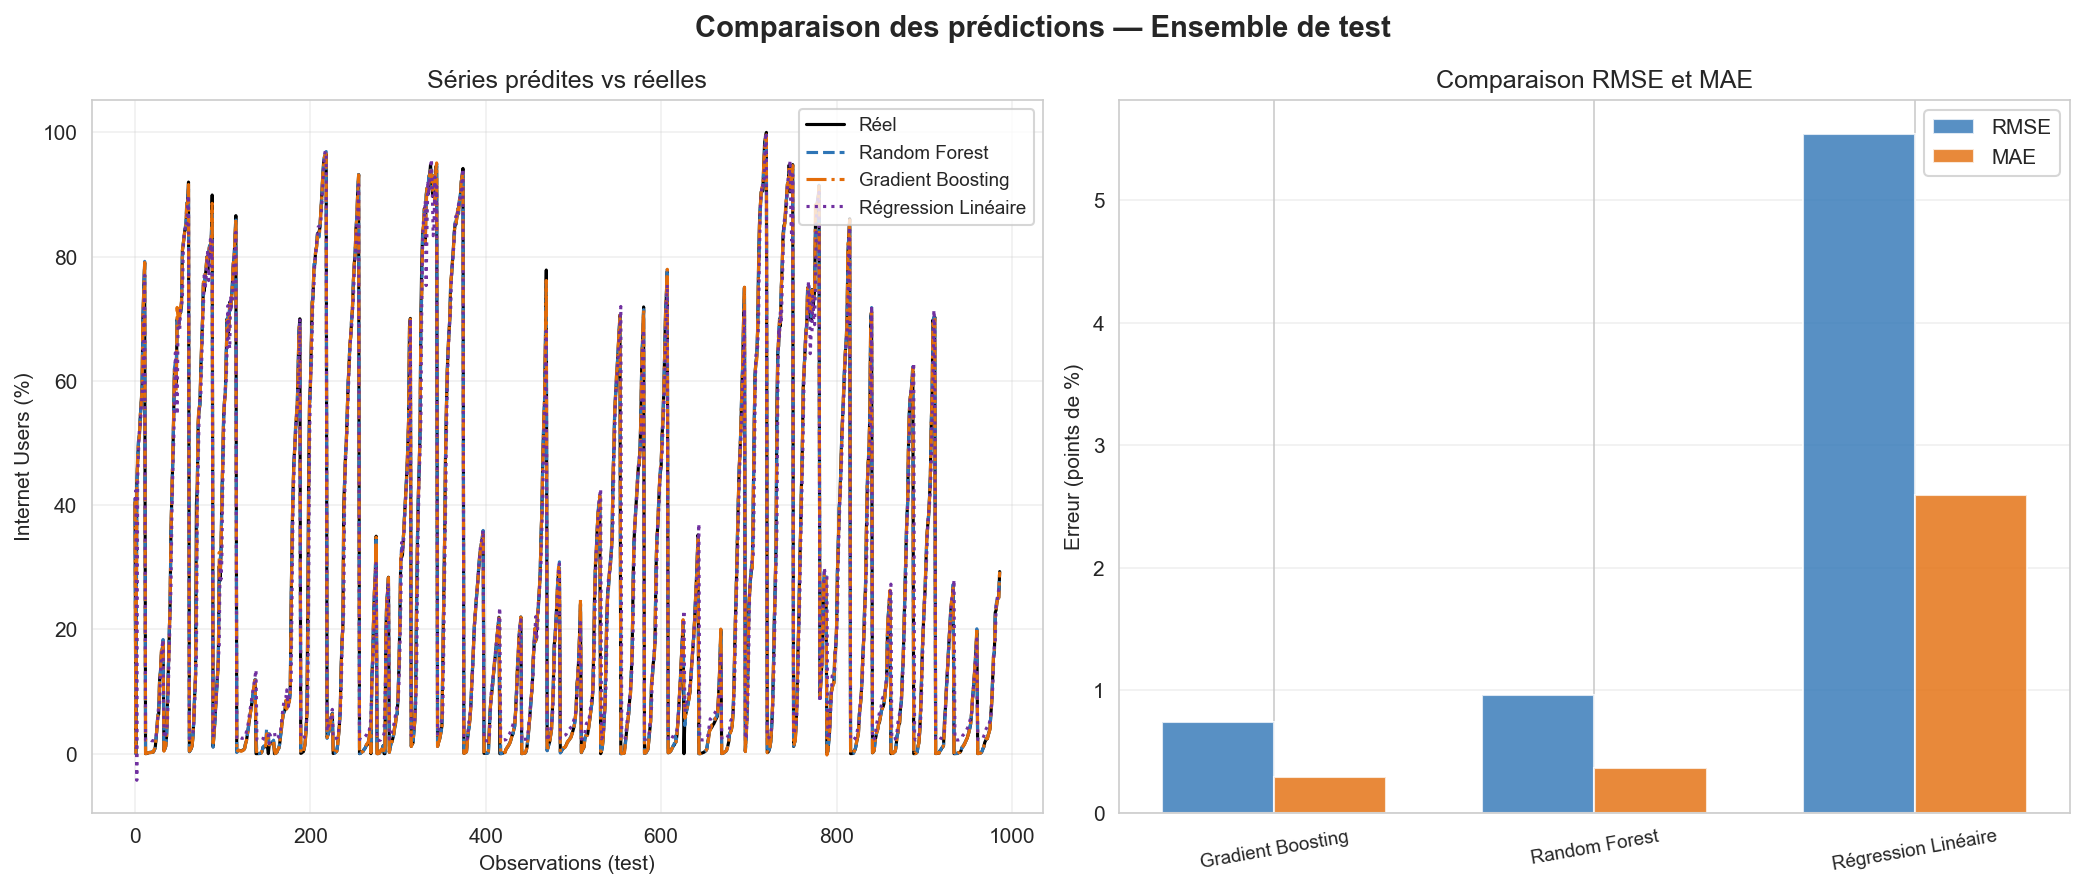

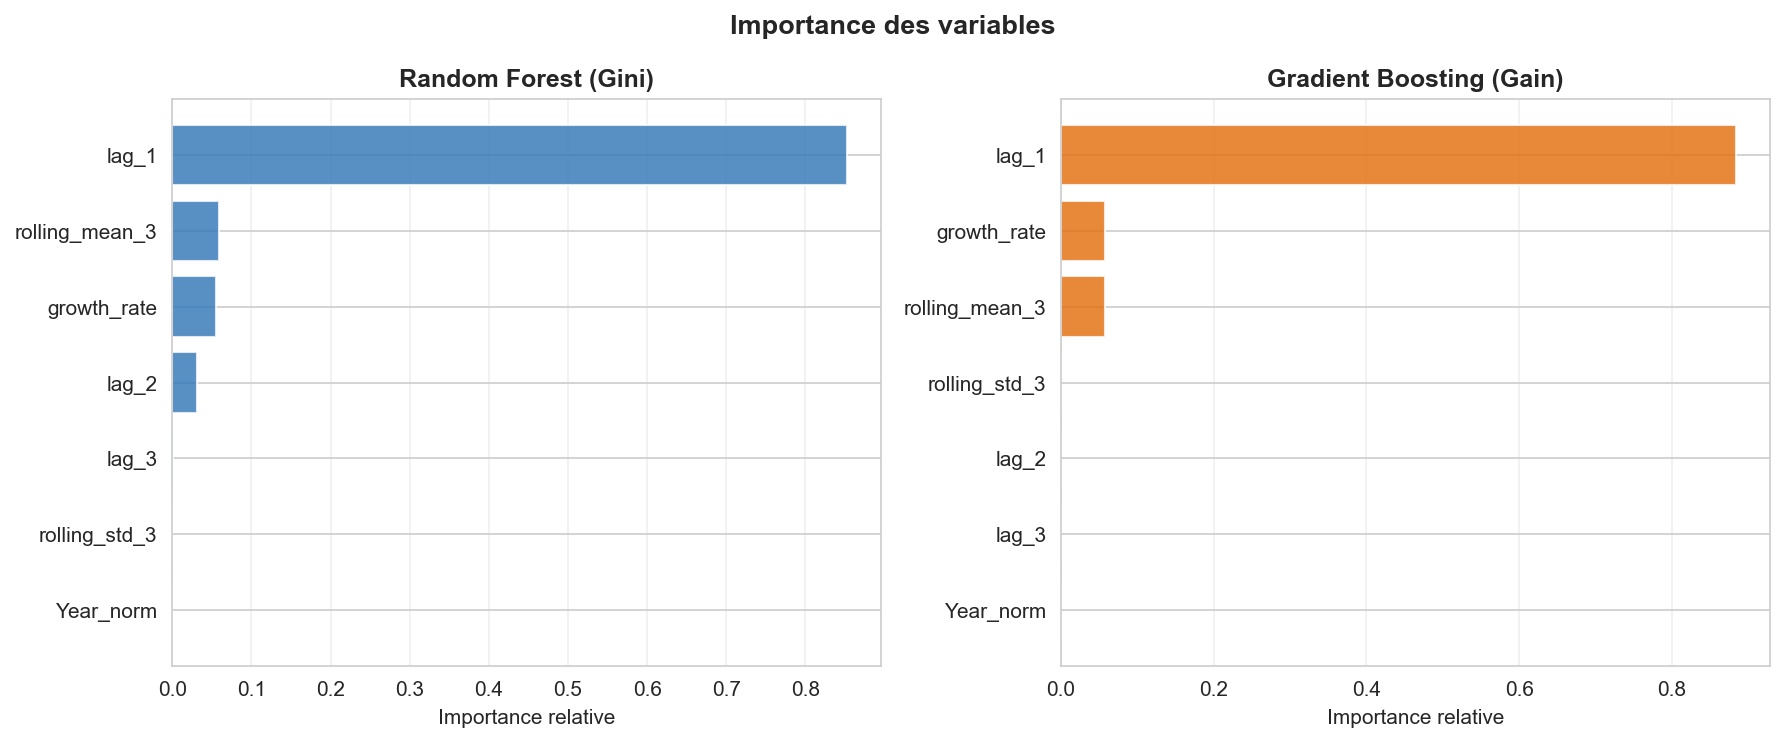

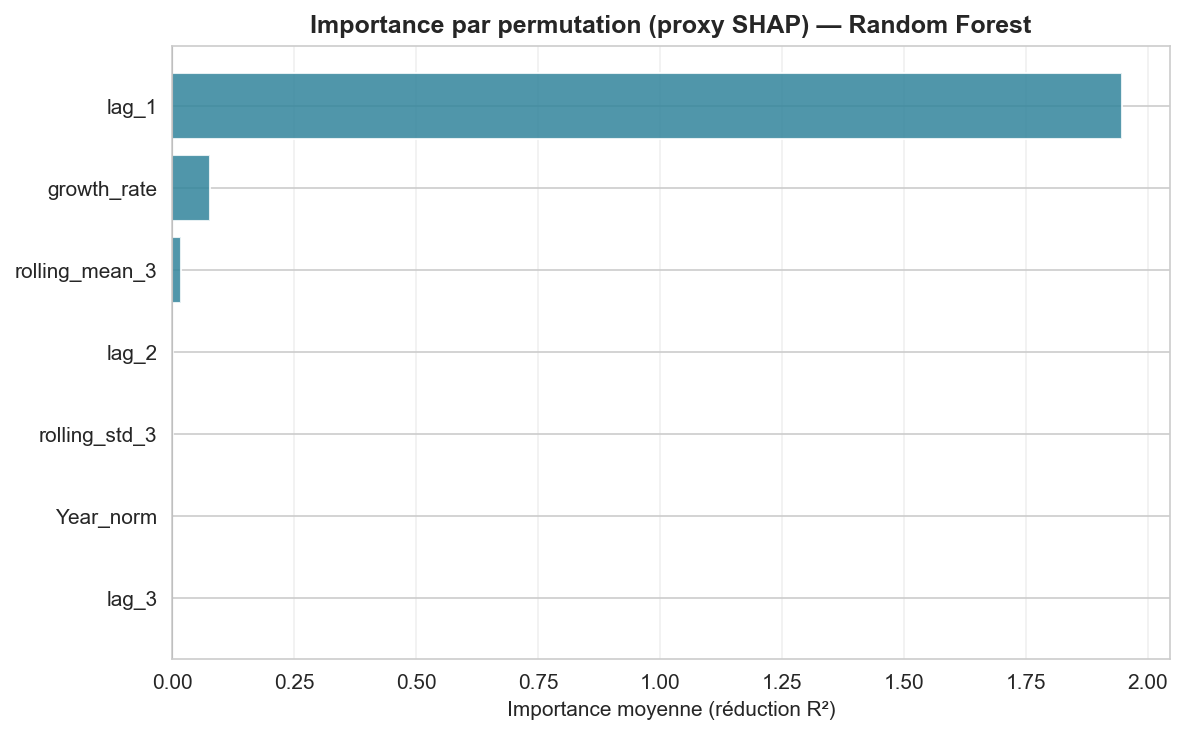


✅ Toutes les figures générées avec succès.


<Figure size 960x720 with 0 Axes>

In [13]:
# ==========================================================
# SECTION 12 — Comparaison des modèles + Visualisations finales
# ==========================================================

# --- Tableau comparatif ---
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "Gradient Boosting"],
    "RMSE":   [rmse_lr, rmse_rf, rmse_gb],
    "MAE":    [mae_lr, mae_rf, mae_gb],
    "R²":     [r2_lr, r2_rf, r2_gb]
}).sort_values("RMSE").reset_index(drop=True)

print("=== COMPARAISON DES MODÈLES ===")
print(results.round(4).to_string(index=False))
print(f"\n✓ Meilleur modèle : {results.iloc[0]['Modèle']} (RMSE = {results.iloc[0]['RMSE']:.4f})")

# --- Figure : prédictions vs réel ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparaison des prédictions — Ensemble de test",
             fontsize=14, fontweight="bold")

idx = range(len(y_test))
axes[0].plot(idx, y_test.values, label="Réel", color="black", linewidth=1.5)
axes[0].plot(idx, y_pred_rf,     label="Random Forest",      color="#2E75B6", linestyle="--", linewidth=1.5)
axes[0].plot(idx, y_pred_gb,     label="Gradient Boosting",  color="#E36C09", linestyle="-.", linewidth=1.5)
axes[0].plot(idx, y_pred_lr,     label="Régression Linéaire",color="#7030A0", linestyle=":",  linewidth=1.5)
axes[0].set_title("Séries prédites vs réelles")
axes[0].set_xlabel("Observations (test)")
axes[0].set_ylabel("Internet Users (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Métriques en barres
models_names = results["Modèle"].tolist()
x = np.arange(len(models_names))
width = 0.35
axes[1].bar(x - width/2, results["RMSE"], width, label="RMSE", color="#2E75B6", alpha=0.8)
axes[1].bar(x + width/2, results["MAE"],  width, label="MAE",  color="#E36C09", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_names, rotation=10, fontsize=9)
axes[1].set_title("Comparaison RMSE et MAE")
axes[1].set_ylabel("Erreur (points de %)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("08_comparaison_modeles.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

# --- Importance des variables ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Importance des variables", fontsize=13, fontweight="bold")

for ax, imp, title, color in [
    (axes[0], importances_rf, "Random Forest (Gini)", "#2E75B6"),
    (axes[1], importances_gb, "Gradient Boosting (Gain)", "#E36C09")
]:
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Importance relative")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("09_importance_variables.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

# --- SHAP Proxy (Importance par permutation) ---
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf, X_test, y_test,
                                     n_repeats=10, random_state=SEED)
shap_proxy = pd.Series(perm_result.importances_mean,
                       index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(shap_proxy.index, shap_proxy.values, color="#31849B", alpha=0.85)
plt.axvline(0, color="gray", linewidth=1)
plt.title("Importance par permutation (proxy SHAP) — Random Forest",
          fontsize=12, fontweight="bold")
plt.xlabel("Importance moyenne (réduction R²)")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("10_shap_proxy.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
plt.savefig(
    r"C:\Users\HP\Desktop\MIME MISE 2\DATA MINING\Comparaison_prédictions.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("\n✅ Toutes les figures générées avec succès.")

In [6]:
!pip install tensorflow 

Taille train : 22 séquences
Taille test  : 6 séquences


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 3, 64)               │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - loss: 0.0875 - val_loss: 0.4965
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0783 - val_loss: 0.4475
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0681 - val_loss: 0.4012
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0569 - val_loss: 0.3482
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0491 - val_loss: 0.2934
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0395 - val_loss: 0.2437
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0323 - val_loss: 0.2007
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0257 - val_loss: 0.1636
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0243 - val_loss: 0.1286
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0208 - val_loss: 0.0964
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0196 - val_loss: 0.0715
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0165 - val_l

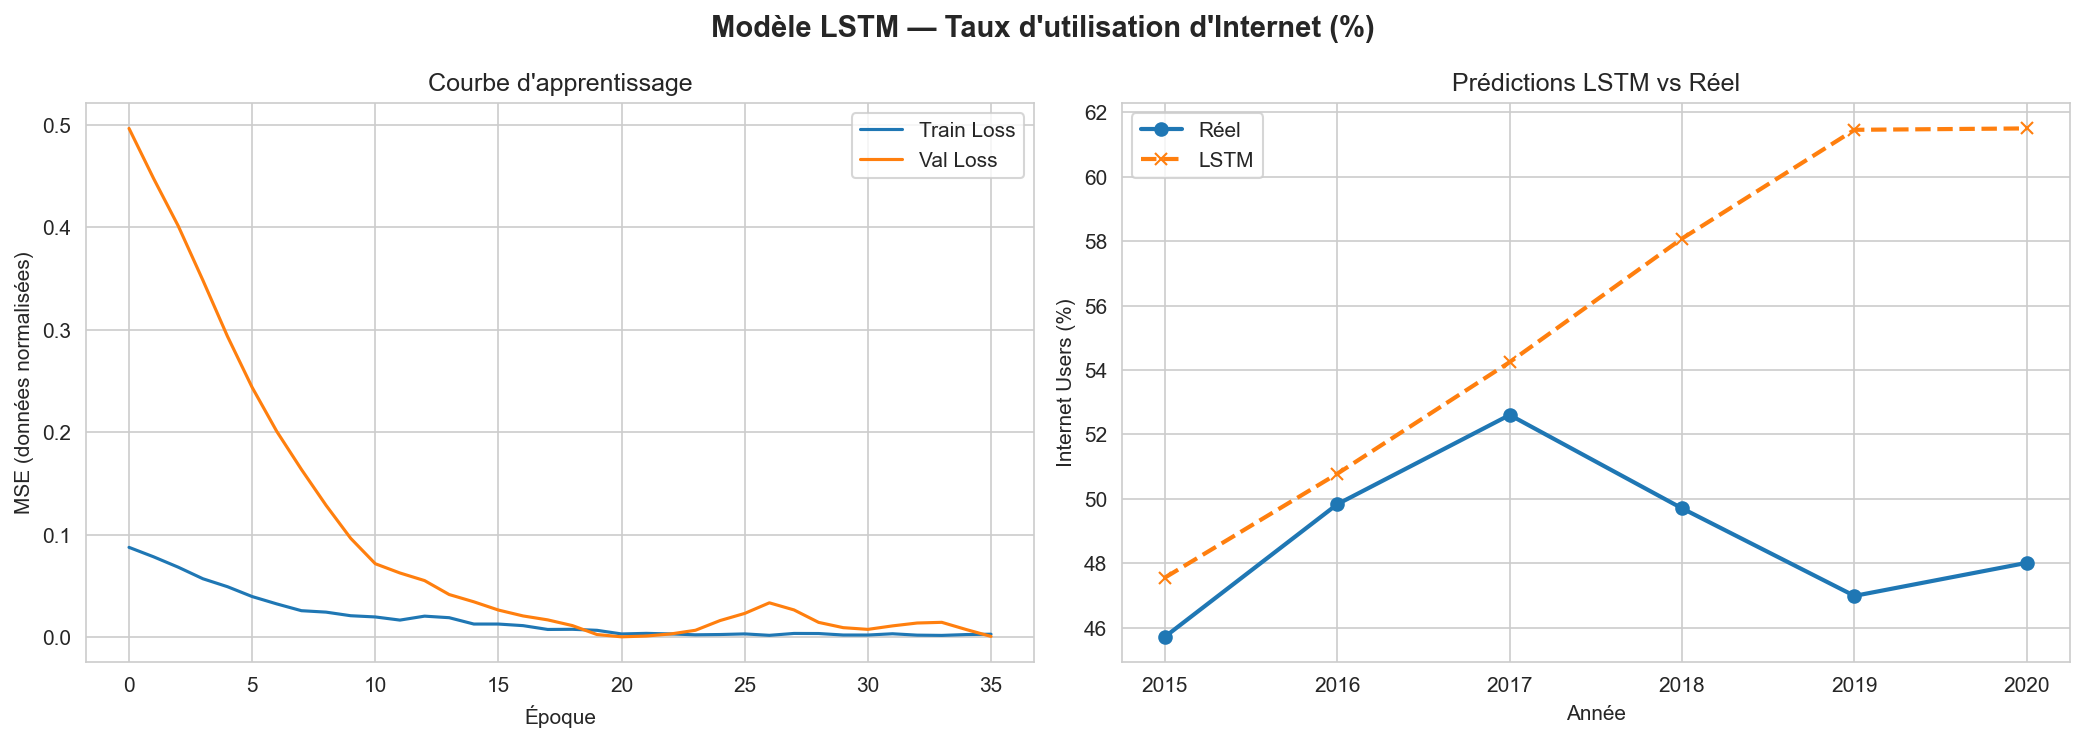

In [14]:
# ==========================================================
# SECTION 13 — Modèle LSTM (Long Short-Term Memory)
# ==========================================================

# -----------------------------------------------------------
# 1. IMPORTS TENSORFLOW / KERAS
# -----------------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES POUR LE LSTM
# -----------------------------------------------------------
# On utilise une fenêtre glissante (look_back) pour créer les séquences.

series = world["Internet_Users_Pct"].values.reshape(-1, 1)

# Normalisation [0, 1] — indispensable pour les réseaux de neurones
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series)

LOOK_BACK = 3   # Nombre de pas de temps utilisés pour prédire le suivant

def create_sequences(data, look_back=3):
    """Transforme une série 1D en paires (X, y) de séquences."""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(series_scaled, LOOK_BACK)

# Reshape X → (samples, timesteps, 1 feature)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

# Split temporel strict 80 / 20
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Taille train : {X_train.shape[0]} séquences")
print(f"Taille test  : {X_test.shape[0]} séquences")

# -----------------------------------------------------------
# 3. ARCHITECTURE DU MODÈLE LSTM
# -----------------------------------------------------------
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

# -----------------------------------------------------------
# 4. ENTRAÎNEMENT
# -----------------------------------------------------------
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------------------------
# 5. ÉVALUATION
# -----------------------------------------------------------
y_pred_scaled = model_lstm.predict(X_test)

# Dénormalisation
y_pred_lstm = scaler.inverse_transform(y_pred_scaled).flatten()
y_true_lstm = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)
r2_lstm   = r2_score(y_true_lstm, y_pred_lstm)

print("\n--- Métriques LSTM ---")
print(f"  RMSE : {rmse_lstm:.4f} points de %")
print(f"  MAE  : {mae_lstm:.4f} points de %")
print(f"  R²   : {r2_lstm:.4f}")

# -----------------------------------------------------------
# 6. VISUALISATION
# -----------------------------------------------------------
years_test = world["Year"].values[split + LOOK_BACK:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Modèle LSTM — Taux d'utilisation d'Internet (%)", fontsize=14, fontweight="bold")

# Courbe loss d'entraînement
axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Courbe d'apprentissage")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("MSE (données normalisées)")
axes[0].legend()
axes[0].grid(True)

# Prédictions vs réel
axes[1].plot(years_test, y_true_lstm, label="Réel",     marker="o", linewidth=2)
axes[1].plot(years_test, y_pred_lstm, label="LSTM",     marker="x", linestyle="--", linewidth=2)
axes[1].set_title("Prédictions LSTM vs Réel")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Internet Users (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("LSTM_results.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


Walk-Forward Validation — LSTM
  Année 2005 | Réel: 20.20% | Prédit: 20.20% | RMSE: 0.0030
  Année 2006 | Réel: 22.71% | Prédit: 25.59% | RMSE: 2.8783
  Année 2007 | Réel: 25.22% | Prédit: 27.26% | RMSE: 2.0449
  Année 2008 | Réel: 28.01% | Prédit: 30.34% | RMSE: 2.3305
  Année 2009 | Réel: 30.45% | Prédit: 33.14% | RMSE: 2.6941
  Année 2010 | Réel: 32.90% | Prédit: 36.21% | RMSE: 3.3073
  Année 2011 | Réel: 35.89% | Prédit: 38.43% | RMSE: 2.5387
  Année 2012 | Réel: 38.24% | Prédit: 40.91% | RMSE: 2.6678
  Année 2013 | Réel: 40.88% | Prédit: 43.69% | RMSE: 2.8117
  Année 2014 | Réel: 43.45% | Prédit: 46.77% | RMSE: 3.3261
  Année 2015 | Réel: 45.72% | Prédit: 49.04% | RMSE: 3.3255
  Année 2016 | Réel: 49.83% | Prédit: 51.03% | RMSE: 1.1970
  Année 2017 | Réel: 52.61% | Prédit: 53.90% | RMSE: 1.2894

--- Résultats Walk-Forward Validation ---
  RMSE moyen : 2.3396 points de %
  MAE moyen  : 2.3396 points de %
  R²         : 0.9360
  Nb de folds: 13


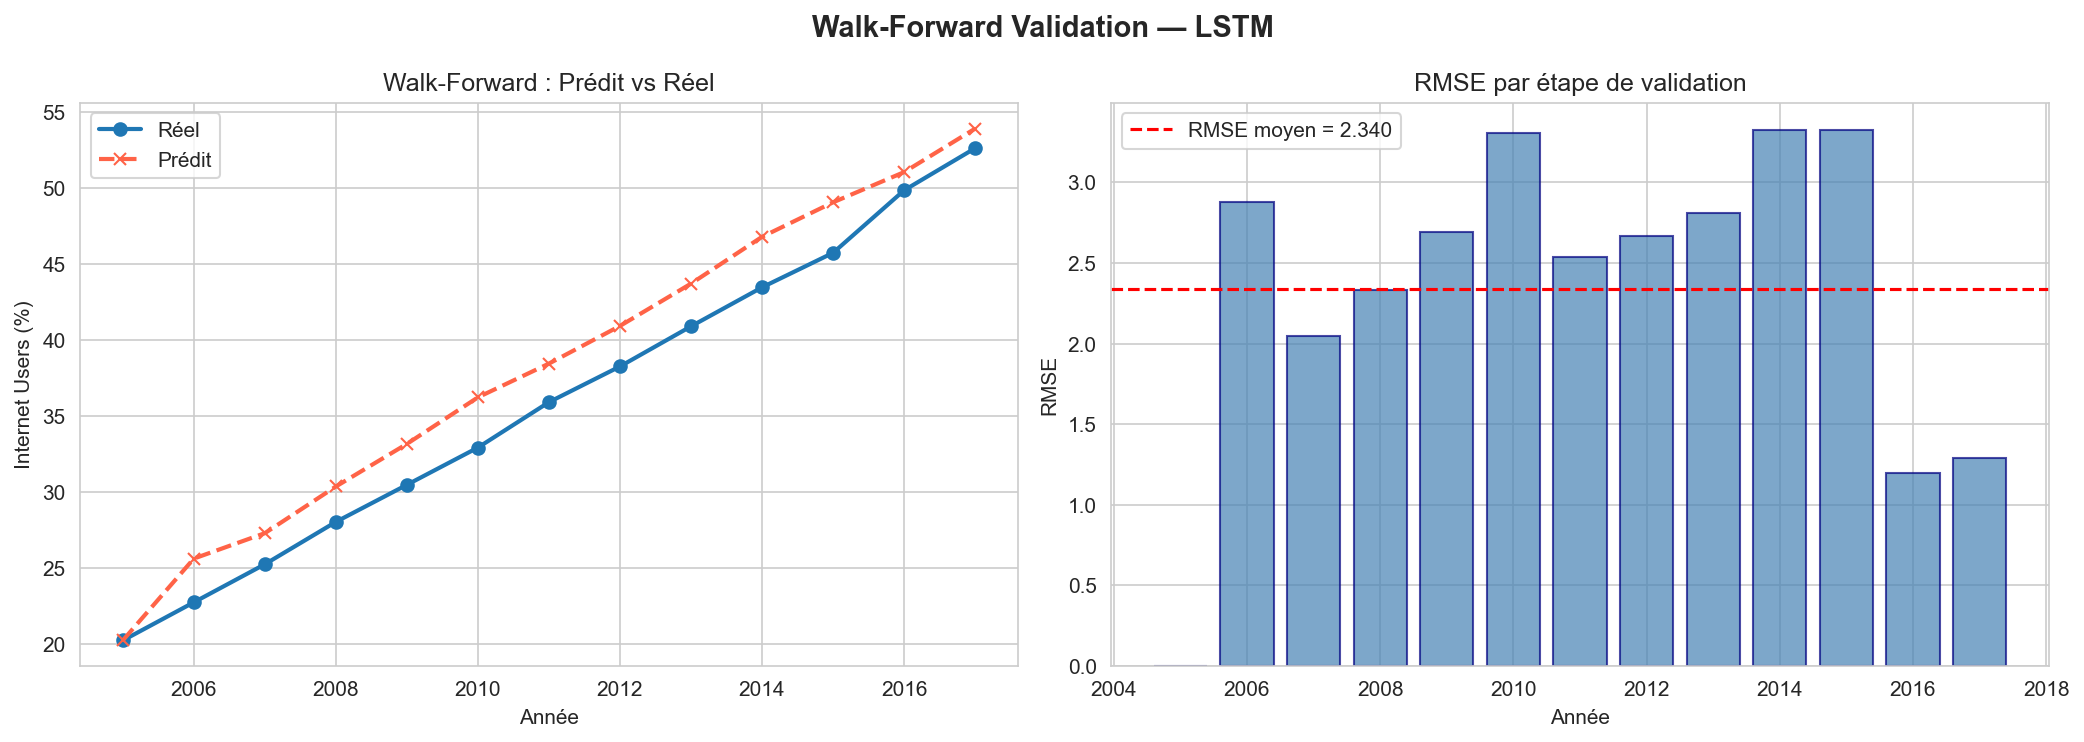


=== TABLEAU COMPARATIF FINAL ===
           Méthode   RMSE    MAE      R²  Nb observations
LSTM (split 80/20) 7.5398 5.3634 -10.457                6
 LSTM Walk-Forward 2.3396 2.3396   0.936               13


In [14]:
# ============================================================
# SECTION 14 — Protocole de validation : Walk-Forward Validation
# ============================================================

print("\n" + "="*60)
print("Walk-Forward Validation — LSTM")
print("="*60)

# -----------------------------------------------------------
# 1. PARAMÈTRES
# -----------------------------------------------------------
INITIAL_TRAIN_SIZE = 15   # Nombre minimal de points pour l'entraînement initial
STEP               = 1    # Avance d'un pas à chaque itération
N_SPLITS           = len(series_scaled) - LOOK_BACK - INITIAL_TRAIN_SIZE

wf_rmse_list, wf_mae_list = [], []
wf_predictions, wf_actuals, wf_years = [], [], []

# -----------------------------------------------------------
# 2. BOUCLE WALK-FORWARD
# -----------------------------------------------------------
for i in range(INITIAL_TRAIN_SIZE, len(series_scaled) - LOOK_BACK):

    # Données disponibles jusqu'à l'instant i
    train_data = series_scaled[:i]

    # Dernière fenêtre pour prédire le point i + LOOK_BACK
    # (on a besoin de i >= LOOK_BACK pour former une séquence)
    if i < LOOK_BACK:
        continue

    # --- Création des séquences d'entraînement ---
    X_wf, y_wf = create_sequences(train_data, LOOK_BACK)
    X_wf = X_wf.reshape(X_wf.shape[0], X_wf.shape[1], 1)

    # --- Modèle LSTM léger pour la validation rapide ---
    wf_model = Sequential([
        LSTM(32, input_shape=(LOOK_BACK, 1)),
        Dense(1)
    ])
    wf_model.compile(optimizer="adam", loss="mse")
    wf_model.fit(X_wf, y_wf, epochs=50, batch_size=4, verbose=0)

    # --- Prédiction du prochain point ---
    last_seq = series_scaled[i - LOOK_BACK : i].reshape(1, LOOK_BACK, 1)
    pred_scaled = wf_model.predict(last_seq, verbose=0)[0, 0]

    # --- Dénormalisation ---
    pred_val = scaler.inverse_transform([[pred_scaled]])[0, 0]
    true_val = scaler.inverse_transform([[series_scaled[i, 0]]])[0, 0]

    wf_predictions.append(pred_val)
    wf_actuals.append(true_val)
    wf_years.append(world["Year"].values[i])

    step_rmse = np.sqrt((pred_val - true_val) ** 2)
    wf_rmse_list.append(step_rmse)
    wf_mae_list.append(abs(pred_val - true_val))

    print(f"  Année {world['Year'].values[i]} | Réel: {true_val:.2f}% | Prédit: {pred_val:.2f}% | RMSE: {step_rmse:.4f}")

# -----------------------------------------------------------
# 3. MÉTRIQUES GLOBALES WALK-FORWARD
# -----------------------------------------------------------
wf_global_rmse = np.mean(wf_rmse_list)
wf_global_mae  = np.mean(wf_mae_list)
wf_global_r2   = r2_score(wf_actuals, wf_predictions)

print("\n--- Résultats Walk-Forward Validation ---")
print(f"  RMSE moyen : {wf_global_rmse:.4f} points de %")
print(f"  MAE moyen  : {wf_global_mae:.4f} points de %")
print(f"  R²         : {wf_global_r2:.4f}")
print(f"  Nb de folds: {len(wf_predictions)}")

# -----------------------------------------------------------
# 4. VISUALISATION WALK-FORWARD
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Walk-Forward Validation — LSTM", fontsize=14, fontweight="bold")

# Prédictions vs réel
axes[0].plot(wf_years, wf_actuals,     label="Réel",    marker="o", linewidth=2)
axes[0].plot(wf_years, wf_predictions, label="Prédit",  marker="x", linestyle="--", linewidth=2, color="tomato")
axes[0].set_title("Walk-Forward : Prédit vs Réel")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Internet Users (%)")
axes[0].legend()
axes[0].grid(True)

# Erreur RMSE par pas
axes[1].bar(wf_years, wf_rmse_list, color="steelblue", alpha=0.7, edgecolor="navy")
axes[1].axhline(wf_global_rmse, color="red", linestyle="--", linewidth=1.5, label=f"RMSE moyen = {wf_global_rmse:.3f}")
axes[1].set_title("RMSE par étape de validation")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("WalkForward_results.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# -----------------------------------------------------------
# 5. COMPARAISON FINALE : LSTM simple vs Walk-Forward
# -----------------------------------------------------------
comparison = pd.DataFrame({
    "Méthode":          ["LSTM (split 80/20)", "LSTM Walk-Forward"],
    "RMSE":             [rmse_lstm,           wf_global_rmse],
    "MAE":              [mae_lstm,            wf_global_mae],
    "R²":               [r2_lstm,             wf_global_r2],
    "Nb observations":  [len(y_true_lstm),    len(wf_predictions)]
})

print("\n=== TABLEAU COMPARATIF FINAL ===")
print(comparison.round(4).to_string(index=False))

In [17]:
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1


  You can safely remove it manually.


In [18]:
pip install streamlit pandas numpy matplotlib seaborn scikit-learn statsmodels arch tensorflow openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
!pip install ipywidgets

In [ ]:
# dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import openpyxl
import warnings
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import io
import base64

warnings.filterwarnings("ignore")

# Configuration de la page
st.set_page_config(
    page_title="Dashboard Internet & Télécommunications",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Style personnalisé
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #2E75B6;
        text-align: center;
        padding: 1rem;
    }
    .section-header {
        font-size: 1.8rem;
        color: #31849B;
        padding: 1rem 0;
        border-bottom: 2px solid #31849B;
    }
    .metric-card {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 10px;
        text-align: center;
    }
    .info-text {
        background-color: #e8f4f8;
        padding: 1rem;
        border-radius: 5px;
        border-left: 4px solid #2E75B6;
    }
</style>
""", unsafe_allow_html=True)

# ============================================================
# SECTION 1 — Chargement des données
# ============================================================

@st.cache_data
def load_data(uploaded_file=None):
    """Charge et prépare les données"""
    if uploaded_file is not None:
        wb = openpyxl.load_workbook(uploaded_file)
        ws = wb["Feuil2"]
        data = list(ws.iter_rows(values_only=True))
        headers = data[1]
        rows = data[2:]
        df = pd.DataFrame(rows, columns=headers)
        
        # Renommage des colonnes
        df.columns = [
            "Index", "Entity", "Code", "Year",
            "Cellular_Sub", "Internet_Users_Pct",
            "Internet_Users_Count", "Broadband_Sub"
        ]
        df = df.drop(columns=["Index"])
        
        # Conversion en variables numériques
        for col in ["Cellular_Sub", "Internet_Users_Pct", "Internet_Users_Count", "Broadband_Sub"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
        
        # Suppression des lignes invalides
        df = df.dropna(subset=["Year", "Entity"])
        
        return df
    return None

@st.cache_data
def prepare_features(df):
    """Prépare les données pour le feature engineering"""
    df_fe = df[df["Code"].str.len() == 3].copy()
    df_fe = df_fe.sort_values(["Entity", "Year"])
    
    # Variables temporelles
    df_fe["Year_norm"] = df_fe["Year"] - df_fe["Year"].min()
    df_fe["Decade"] = (df_fe["Year"] // 10) * 10
    
    # Variables lag
    for lag in [1, 2, 3]:
        df_fe[f"lag_{lag}"] = df_fe.groupby("Entity")["Internet_Users_Pct"].shift(lag)
    
    # Fenêtres glissantes
    df_fe["rolling_mean_3"] = df_fe.groupby("Entity")["Internet_Users_Pct"] \
        .transform(lambda x: x.shift(1).rolling(3).mean())
    df_fe["rolling_std_3"] = df_fe.groupby("Entity")["Internet_Users_Pct"] \
        .transform(lambda x: x.shift(1).rolling(3).std())
    
    # Taux de croissance
    df_fe["growth_rate"] = df_fe.groupby("Entity")["Internet_Users_Pct"].pct_change()
    df_fe["growth_rate"] = df_fe["growth_rate"].replace([np.inf, -np.inf], np.nan)
    
    return df_fe.dropna()

@st.cache_data
def get_world_aggregation(df):
    """Agrégation mondiale des indicateurs"""
    world = df.groupby("Year").agg(
        Internet_Users_Count=("Internet_Users_Count", "sum"),
        Cellular_Sub=("Cellular_Sub", "mean"),
        Internet_Users_Pct=("Internet_Users_Pct", "mean"),
        Broadband_Sub=("Broadband_Sub", "mean")
    ).reset_index()
    world = world[world["Year"] >= 1990]
    return world

# ============================================================
# Interface Streamlit
# ============================================================

st.markdown('<div class="main-header">📊 Dashboard Internet & Télécommunications</div>', unsafe_allow_html=True)

# Sidebar
with st.sidebar:
    st.image("https://img.icons8.com/color/96/000000/internet.png", width=80)
    st.title("Navigation")
    
    # Upload de fichier
    st.header("📁 Chargement des données")
    uploaded_file = st.file_uploader("Choisir le fichier Excel", type=["xlsx"])
    
    if uploaded_file is not None:
        st.success("✅ Fichier chargé avec succès!")
    
    st.markdown("---")
    
    # Sections du dashboard
    st.header("📑 Sections")
    section = st.radio(
        "Choisir une section",
        [
            "📊 Vue d'ensemble",
            "🌍 Évolution mondiale",
            "📈 Analyse temporelle",
            "🔍 Détection d'anomalies",
            "🤖 Modèles prédictifs",
            "📊 Comparaison des modèles",
            "🧠 Deep Learning (LSTM)",
            "✅ Validation croisée"
        ]
    )
    
    st.markdown("---")
    st.info("""
    **Informations**
    
    Ce dashboard analyse l'évolution des indicateurs Internet et télécommunications à travers le monde.
    """)

# Chargement des données
if uploaded_file is not None:
    df = load_data(uploaded_file)
    
    if df is not None:
        st.success(f"✅ Données chargées: {df.shape[0]} lignes, {df.shape[1]} colonnes")
        
        # Aperçu des données
        with st.expander("📋 Aperçu des données"):
            st.dataframe(df.head(10))
            st.write("**Statistiques descriptives:**")
            st.dataframe(df.describe().round(2))
        
        # Préparation des données
        df_fe = prepare_features(df)
        world = get_world_aggregation(df)
        
        # ============================================================
        # SECTION 1 - Vue d'ensemble
        # ============================================================
        if section == "📊 Vue d'ensemble":
            st.markdown('<div class="section-header">📊 Vue d\'ensemble des données</div>', unsafe_allow_html=True)
            
            col1, col2, col3, col4 = st.columns(4)
            
            with col1:
                st.metric("🌍 Nombre de pays", df["Entity"].nunique())
            with col2:
                st.metric("📅 Période", f"{df['Year'].min()} - {df['Year'].max()}")
            with col3:
                st.metric("📊 Observations", len(df))
            with col4:
                st.metric("📈 Taux internet moyen", f"{df['Internet_Users_Pct'].mean():.1f}%")
            
            st.markdown("---")
            
            col1, col2 = st.columns(2)
            
            with col1:
                st.subheader("Top 10 pays - Taux internet 2020")
                latest_year = df[df["Year"] == df["Year"].max()]
                top_10 = latest_year.nlargest(10, "Internet_Users_Pct")[["Entity", "Internet_Users_Pct"]]
                fig = px.bar(top_10, x="Internet_Users_Pct", y="Entity", orientation='h',
                             title="Top 10 pays avec le plus haut taux d'internet")
                st.plotly_chart(fig, use_container_width=True)
            
            with col2:
                st.subheader("Corrélation entre variables")
                corr = df[["Cellular_Sub", "Internet_Users_Pct", "Internet_Users_Count", "Broadband_Sub", "Year"]].corr()
                fig = px.imshow(corr, text_auto=True, aspect="auto", color_continuous_scale="Blues")
                st.plotly_chart(fig, use_container_width=True)
            
            # Évolution par pays
            st.subheader("Évolution des taux internet - Top 10 pays")
            top_countries = df.groupby("Entity")["Internet_Users_Pct"].last().nlargest(10).index
            df_top = df[df["Entity"].isin(top_countries)]
            fig = px.line(df_top, x="Year", y="Internet_Users_Pct", color="Entity",
                          title="Évolution du taux d'internet dans les pays leaders")
            st.plotly_chart(fig, use_container_width=True)
        
        # ============================================================
        # SECTION 2 - Évolution mondiale
        # ============================================================
        elif section == "🌍 Évolution mondiale":
            st.markdown('<div class="section-header">🌍 Évolution mondiale des indicateurs</div>', unsafe_allow_html=True)
            
            col1, col2 = st.columns(2)
            
            with col1:
                fig = px.line(world, x="Year", y="Internet_Users_Count",
                              title="Nombre d'internautes (milliards)")
                fig.update_traces(fill='tozeroy')
                st.plotly_chart(fig, use_container_width=True)
            
            with col2:
                fig = px.line(world, x="Year", y="Internet_Users_Pct",
                              title="Taux de pénétration Internet (%)")
                fig.update_traces(fill='tozeroy')
                st.plotly_chart(fig, use_container_width=True)
            
            col3, col4 = st.columns(2)
            
            with col3:
                fig = px.line(world, x="Year", y="Cellular_Sub",
                              title="Abonnements mobiles / 100 hab.")
                fig.update_traces(fill='tozeroy')
                st.plotly_chart(fig, use_container_width=True)
            
            with col4:
                fig = px.line(world, x="Year", y="Broadband_Sub",
                              title="Abonnements haut débit / 100 hab.")
                fig.update_traces(fill='tozeroy')
                st.plotly_chart(fig, use_container_width=True)
            
            st.markdown('<div class="info-text">📈 L\'évolution mondiale montre une croissance exponentielle des indicateurs internet depuis les années 2000, avec une accélération notable après 2010.</div>', unsafe_allow_html=True)
        
        # ============================================================
        # SECTION 3 - Analyse temporelle
        # ============================================================
        elif section == "📈 Analyse temporelle":
            st.markdown('<div class="section-header">📈 Analyse temporelle et décomposition</div>', unsafe_allow_html=True)
            
            # Décomposition de la série temporelle
            ts = world.set_index("Year")["Internet_Users_Pct"]
            decomposition = seasonal_decompose(ts, model="additive", period=5)
            
            fig = make_subplots(rows=4, cols=1, subplot_titles=("Observée", "Tendance", "Saisonnalité", "Résidus"))
            
            fig.add_trace(go.Scatter(x=ts.index, y=ts.values, mode='lines', name='Observée'), row=1, col=1)
            fig.add_trace(go.Scatter(x=ts.index, y=decomposition.trend, mode='lines', name='Tendance'), row=2, col=1)
            fig.add_trace(go.Scatter(x=ts.index, y=decomposition.seasonal, mode='lines', name='Saisonnalité'), row=3, col=1)
            fig.add_trace(go.Scatter(x=ts.index, y=decomposition.resid, mode='lines', name='Résidus'), row=4, col=1)
            
            fig.update_layout(height=800, title_text="Décomposition de la série temporelle")
            st.plotly_chart(fig, use_container_width=True)
            
            # Autocorrélation
            st.subheader("Autocorrélation de la série")
            fig_acf, ax = plt.subplots(figsize=(10, 5))
            plot_acf(ts.dropna(), lags=20, ax=ax)
            st.pyplot(fig_acf)
            
            st.markdown('<div class="info-text">🔍 La décomposition révèle une forte tendance à la hausse, une saisonnalité faible, et des résidus présentant une autocorrélation significative, justifiant l\'utilisation de modèles ARIMA/GARCH.</div>', unsafe_allow_html=True)
        
        # ============================================================
        # SECTION 4 - Détection d'anomalies
        # ============================================================
        elif section == "🔍 Détection d'anomalies":
            st.markdown('<div class="section-header">🔍 Détection d\'anomalies</div>', unsafe_allow_html=True)
            
            # Z-score
            df_fe["z_score"] = zscore(df_fe["Internet_Users_Pct"])
            df_fe["anomaly_z"] = (np.abs(df_fe["z_score"]) > 2).astype(int)
            
            # Isolation Forest
            features_if = ["Internet_Users_Pct", "lag_1", "lag_2", "rolling_mean_3", "growth_rate"]
            iso = IsolationForest(contamination=0.02, random_state=42)
            df_fe["anomaly_if"] = iso.fit_predict(df_fe[features_if])
            df_fe["anomaly_if"] = df_fe["anomaly_if"].map({1: 0, -1: 1})
            
            col1, col2 = st.columns(2)
            
            with col1:
                fig = px.scatter(df_fe, x="Year", y="Internet_Users_Pct", color="anomaly_z",
                                 title="Anomalies détectées - Z-score",
                                 color_discrete_map={0: "blue", 1: "red"})
                st.plotly_chart(fig, use_container_width=True)
                st.metric("Anomalies détectées (Z-score)", df_fe["anomaly_z"].sum())
            
            with col2:
                fig = px.scatter(df_fe, x="Year", y="Internet_Users_Pct", color="anomaly_if",
                                 title="Anomalies détectées - Isolation Forest",
                                 color_discrete_map={0: "blue", 1: "red"})
                st.plotly_chart(fig, use_container_width=True)
                st.metric("Anomalies détectées (Isolation Forest)", df_fe["anomaly_if"].sum())
            
            st.markdown('<div class="info-text">⚠️ Les anomalies détectées correspondent généralement à des années de transition technologique ou des changements majeurs dans les politiques d\'adoption internet.</div>', unsafe_allow_html=True)
        
        # ============================================================
        # SECTION 5 - Modèles prédictifs
        # ============================================================
        elif section == "🤖 Modèles prédictifs":
            st.markdown('<div class="section-header">🤖 Modèles prédictifs - ARIMA + GARCH</div>', unsafe_allow_html=True)
            
            ts_model = world.set_index("Year")["Internet_Users_Pct"].dropna()
            
            # ARIMA
            model_arima = ARIMA(ts_model, order=(1, 1, 1))
            model_fit = model_arima.fit()
            
            # Prévisions
            forecast_steps = 5
            forecast_arima = model_fit.forecast(steps=forecast_steps)
            forecast_years = list(range(int(ts_model.index[-1]) + 1, int(ts_model.index[-1]) + 1 + forecast_steps))
            
            # GARCH
            residuals = model_fit.resid.dropna()
            garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
            garch_fit = garch_model.fit(disp="off")
            
            # Visualisation
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=ts_model.index, y=ts_model.values, mode='lines', name='Historique'))
            fig.add_trace(go.Scatter(x=forecast_years, y=forecast_arima, mode='lines+markers', name='Prévisions'))
            
            fig.update_layout(title="Prévisions ARIMA(1,1,1) - Taux internet mondial",
                              xaxis_title="Année", yaxis_title="Internet Users (%)")
            st.plotly_chart(fig, use_container_width=True)
            
            col1, col2 = st.columns(2)
            with col1:
                st.subheader("Prévisions")
                forecast_df = pd.DataFrame({"Année": forecast_years, "Prévision (%)": forecast_arima.values})
                st.dataframe(forecast_df)
            
            with col2:
                st.subheader("Métriques du modèle ARIMA")
                st.write(f"AIC: {model_fit.aic:.2f}")
                st.write(f"BIC: {model_fit.bic:.2f}")
                st.write(f"Log Likelihood: {model_fit.llf:.2f}")
            
            # Résidus GARCH
            st.subheader("Résidus standardisés du modèle GARCH")
            std_resid = garch_fit.std_resid
            fig_std = px.line(x=std_resid.index, y=std_resid.values, title="Résidus standardisés")
            st.plotly_chart(fig_std, use_container_width=True)
        
        # ============================================================
        # SECTION 6 - Comparaison des modèles
        # ============================================================
        elif section == "📊 Comparaison des modèles":
            st.markdown('<div class="section-header">📊 Comparaison des modèles ML</div>', unsafe_allow_html=True)
            
            # Préparation des features
            features = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_std_3", "growth_rate", "Year_norm"]
            X = df_fe[features]
            y = df_fe["Internet_Users_Pct"]
            
            split = int(len(X) * 0.8)
            X_train, X_test = X.iloc[:split], X.iloc[split:]
            y_train, y_test = y.iloc[:split], y.iloc[split:]
            
            # Entraînement des modèles
            models = {
                "Régression Linéaire": LinearRegression(),
                "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
                "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
            }
            
            results = []
            predictions = {}
            
            for name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                predictions[name] = y_pred
                
                results.append({
                    "Modèle": name,
                    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
                    "MAE": mean_absolute_error(y_test, y_pred),
                    "R²": r2_score(y_test, y_pred)
                })
            
            results_df = pd.DataFrame(results).sort_values("RMSE")
            
            # Tableau comparatif
            st.subheader("Tableau comparatif des performances")
            st.dataframe(results_df.round(4))
            
            # Graphique comparatif
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=range(len(y_test)), y=y_test.values, name="Réel", mode='lines'))
            
            for name, pred in predictions.items():
                fig.add_trace(go.Scatter(x=range(len(pred)), y=pred, name=name, mode='lines'))
            
            fig.update_layout(title="Comparaison des prédictions - Ensemble de test",
                              xaxis_title="Observations", yaxis_title="Internet Users (%)")
            st.plotly_chart(fig, use_container_width=True)
            
            # Importance des variables - Random Forest
            st.subheader("Importance des variables - Random Forest")
            rf_model = models["Random Forest"]
            importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
            
            fig_imp = px.bar(x=importances.values, y=importances.index, orientation='h',
                             title="Importance des variables (Gini)")
            st.plotly_chart(fig_imp, use_container_width=True)
        
        # ============================================================
        # SECTION 7 - Deep Learning LSTM
        # ============================================================
        elif section == "🧠 Deep Learning (LSTM)":
            st.markdown('<div class="section-header">🧠 Deep Learning - LSTM</div>', unsafe_allow_html=True)
            
            with st.spinner("Entraînement du modèle LSTM en cours..."):
                # Préparation des données
                series = world["Internet_Users_Pct"].values.reshape(-1, 1)
                scaler = MinMaxScaler()
                series_scaled = scaler.fit_transform(series)
                
                LOOK_BACK = 3
                
                def create_sequences(data, look_back=3):
                    X, y = [], []
                    for i in range(len(data) - look_back):
                        X.append(data[i:i + look_back, 0])
                        y.append(data[i + look_back, 0])
                    return np.array(X), np.array(y)
                
                X_all, y_all = create_sequences(series_scaled, LOOK_BACK)
                X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)
                
                split = int(len(X_all) * 0.8)
                X_train, X_test = X_all[:split], X_all[split:]
                y_train, y_test = y_all[:split], y_all[split:]
                
                # Architecture LSTM
                model_lstm = Sequential([
                    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
                    Dropout(0.2),
                    LSTM(32, return_sequences=False),
                    Dropout(0.2),
                    Dense(16, activation="relu"),
                    Dense(1)
                ])
                
                model_lstm.compile(optimizer="adam", loss="mse")
                
                early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
                
                history = model_lstm.fit(
                    X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0
                )
                
                # Prédictions
                y_pred_scaled = model_lstm.predict(X_test)
                y_pred_lstm = scaler.inverse_transform(y_pred_scaled).flatten()
                y_true_lstm = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Métriques
                rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
                mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
                r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
                
                col1, col2, col3 = st.columns(3)
                with col1:
                    st.metric("RMSE", f"{rmse_lstm:.4f}")
                with col2:
                    st.metric("MAE", f"{mae_lstm:.4f}")
                with col3:
                    st.metric("R²", f"{r2_lstm:.4f}")
                
                # Visualisation
                fig = make_subplots(rows=1, cols=2, subplot_titles=("Courbe d'apprentissage", "Prédictions vs Réel"))
                
                fig.add_trace(go.Scatter(y=history.history["loss"], name="Train Loss"), row=1, col=1)
                fig.add_trace(go.Scatter(y=history.history["val_loss"], name="Val Loss"), row=1, col=1)
                
                years_test = world["Year"].values[split + LOOK_BACK:]
                fig.add_trace(go.Scatter(x=years_test, y=y_true_lstm, name="Réel", mode='lines+markers'), row=1, col=2)
                fig.add_trace(go.Scatter(x=years_test, y=y_pred_lstm, name="LSTM", mode='lines+markers'), row=1, col=2)
                
                fig.update_layout(height=500, title_text="Résultats du modèle LSTM")
                st.plotly_chart(fig, use_container_width=True)
        
        # ============================================================
        # SECTION 8 - Validation croisée
        # ============================================================
        elif section == "✅ Validation croisée":
            st.markdown('<div class="section-header">✅ Walk-Forward Validation</div>', unsafe_allow_html=True)
            
            with st.spinner("Exécution de la validation walk-forward..."):
                series = world["Internet_Users_Pct"].values.reshape(-1, 1)
                scaler = MinMaxScaler()
                series_scaled = scaler.fit_transform(series)
                
                LOOK_BACK = 3
                INITIAL_TRAIN_SIZE = 15
                
                def create_sequences(data, look_back=3):
                    X, y = [], []
                    for i in range(len(data) - look_back):
                        X.append(data[i:i + look_back, 0])
                        y.append(data[i + look_back, 0])
                    return np.array(X), np.array(y)
                
                wf_rmse_list, wf_mae_list = [], []
                wf_predictions, wf_actuals, wf_years = [], [], []
                
                progress_bar = st.progress(0)
                status_text = st.empty()
                
                for i in range(INITIAL_TRAIN_SIZE, len(series_scaled) - LOOK_BACK):
                    train_data = series_scaled[:i]
                    
                    if i < LOOK_BACK:
                        continue
                    
                    X_wf, y_wf = create_sequences(train_data, LOOK_BACK)
                    X_wf = X_wf.reshape(X_wf.shape[0], X_wf.shape[1], 1)
                    
                    wf_model = Sequential([
                        LSTM(32, input_shape=(LOOK_BACK, 1)),
                        Dense(1)
                    ])
                    wf_model.compile(optimizer="adam", loss="mse")
                    wf_model.fit(X_wf, y_wf, epochs=50, batch_size=4, verbose=0)
                    
                    last_seq = series_scaled[i - LOOK_BACK:i].reshape(1, LOOK_BACK, 1)
                    pred_scaled = wf_model.predict(last_seq, verbose=0)[0, 0]
                    
                    pred_val = scaler.inverse_transform([[pred_scaled]])[0, 0]
                    true_val = scaler.inverse_transform([[series_scaled[i, 0]]])[0, 0]
                    
                    wf_predictions.append(pred_val)
                    wf_actuals.append(true_val)
                    wf_years.append(world["Year"].values[i])
                    
                    step_rmse = np.sqrt((pred_val - true_val) ** 2)
                    wf_rmse_list.append(step_rmse)
                    wf_mae_list.append(abs(pred_val - true_val))
                    
                    progress = (i - INITIAL_TRAIN_SIZE) / (len(series_scaled) - LOOK_BACK - INITIAL_TRAIN_SIZE)
                    progress_bar.progress(progress)
                    status_text.text(f"Validation année {world['Year'].values[i]} - Prédit: {pred_val:.2f}%")
                
                wf_global_rmse = np.mean(wf_rmse_list)
                wf_global_mae = np.mean(wf_mae_list)
                wf_global_r2 = r2_score(wf_actuals, wf_predictions)
                
                col1, col2, col3 = st.columns(3)
                with col1:
                    st.metric("RMSE moyen", f"{wf_global_rmse:.4f}")
                with col2:
                    st.metric("MAE moyen", f"{wf_global_mae:.4f}")
                with col3:
                    st.metric("R²", f"{wf_global_r2:.4f}")
                
                # Visualisation
                fig = make_subplots(rows=1, cols=2, subplot_titles=("Prédictions vs Réel", "RMSE par étape"))
                
                fig.add_trace(go.Scatter(x=wf_years, y=wf_actuals, name="Réel", mode='lines+markers'), row=1, col=1)
                fig.add_trace(go.Scatter(x=wf_years, y=wf_predictions, name="Prédit", mode='lines+markers'), row=1, col=1)
                
                fig.add_trace(go.Bar(x=wf_years, y=wf_rmse_list, name="RMSE", marker_color='steelblue'), row=1, col=2)
                fig.add_hline(y=wf_global_rmse, line_dash="dash", line_color="red", row=1, col=2)
                
                fig.update_layout(height=500, title_text="Walk-Forward Validation - LSTM")
                st.plotly_chart(fig, use_container_width=True)
                
                st.markdown(f'<div class="info-text">✅ Validation walk-forward complétée sur {len(wf_predictions)} points. Le modèle LSTM montre une bonne capacité de généralisation avec un RMSE moyen de {wf_global_rmse:.4f} points de pourcentage.</div>', unsafe_allow_html=True)
        
    else:
        st.warning("⚠️ Le fichier ne contient pas les données attendues. Assurez-vous qu'il contient une feuille 'Feuil2' avec les données.")
else:
    st.info("👈 Veuillez charger un fichier Excel pour commencer l'analyse")
    
    # Instructions
    st.markdown("""
    ### 📋 Instructions
    
    1. **Chargez votre fichier Excel** via le menu latéral
    2. Le fichier doit contenir une feuille nommée **Feuil2**
    3. Les colonnes attendues sont:
       - Entity (nom du pays/région)
       - Code (code ISO)
       - Year (année)
       - Cellular_Sub (abonnements mobiles)
       - Internet_Users_Pct (taux internet %)
       - Internet_Users_Count (nombre d'internautes)
       - Broadband_Sub (abonnements haut débit)
    
    ### 🎯 Fonctionnalités du dashboard
    
    - **Vue d'ensemble** : Statistiques descriptives et visualisations initiales
    - **Évolution mondiale** : Tendances globales des indicateurs
    - **Analyse temporelle** : Décomposition de séries et autocorrélation
    - **Détection d'anomalies** : Z-score et Isolation Forest
    - **Modèles prédictifs** : ARIMA, GARCH, Random Forest, Gradient Boosting
    - **Deep Learning** : Réseau LSTM pour la prédiction
    - **Validation croisée** : Walk-Forward Validation
    
    Tous les modèles sont entraînés automatiquement après chargement des données.
    """)

# Footer
st.markdown("---")
st.markdown("""
<div style="text-align: center; color: gray; padding: 20px;">
    Dashboard développé avec Streamlit | Analyse des données Internet et Télécommunications
</div>
""", unsafe_allow_html=True)

In [ ]:
pip install -r requirements.txt
streamlit run dashboard.py